Bagaimana korelasi antara Indeks Pembangunan Teknologi Informasi (IPTI) suatu provinsi dengan jumlah lulusan SMA yang tidak melanjutkan ke perguruan tinggi dari tahun 2020 - 2025?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

DATA LOADING

In [ ]:
data_IPTIK_Indonsia_per_provinsi_2019_2020 = pd.read_csv(
    'Data IPTIK 2019 dan 2020.csv'
)
data_IPTIK_Indonsia_per_provinsi_2019_2020

,Provinsi,Nilai IPTIK 2019,Nilai IPTIK 2020
0,11. Aceh,"4,91","5,27"
1,12. Sumatera Utara,"5,19","5,44"
2,13. Sumatera Barat,"5,25","5,52"
3,14. Riau,"5,33","5,74"
4,15. Jambi,"5,17","5,49"
5,16. Sumatera Selatan,"4,91","5,3"
6,17. Bengkulu,"5,21","5,5"
7,18. Lampung,"4,83","5,15"
8,19. Kep. Bangka Belitung,"5,25","5,54"
9,21. Kepulauan Riau,"6,36","6,46"


In [ ]:
data_IPTIK_Indonsia_per_provinsi_2021_2022 = pd.read_csv(
    'Data IPTIK 2021 dan 2022.csv'
)
data_IPTIK_Indonsia_per_provinsi_2021_2022

,Provinsi,Subindeks Akses & Infrastruktur TIK (2021),Subindeks Akses & Infrastruktur TIK (2022),Subindeks Penggunaan TIK (2021),Subindeks Penggunaan TIK (2022),Subindeks Keahlian TIK (2021),Subindeks Keahlian TIK (2022),Indeks Pembangunan TIK (2021),Indeks Pembangunan TIK (2022)
0,11. Aceh,"5,68","5,57","4,78","5,05","6,8","6,77","5,54","5,6"
1,12. Sumatera Utara,"5,81","5,97","5,38","5,61","6,36","6,37","5,75","5,9"
2,13. Sumatera Barat,"6,07","6,11","5,43","5,61","6,59","6,6","5,92","6,01"
3,14. Riau,6,"6,07","5,61","5,84","6,28","6,27","5,9","6,02"
4,15. Jambi,"6,01","5,93","5,36","5,64","5,89","5,87","5,73","5,8"
5,16. Sumatera Selatan,"5,89","5,97","5,39","5,6","5,66","5,67","5,64","5,76"
6,17. Bengkulu,"5,89","6,01","5,52","5,66","6,41","6,4","5,85","5,95"
7,18. Lampung,"5,69","5,65","5,42","5,61","5,66","5,62","5,58","5,63"
8,19. Kep. Bangka Belitung,"6,05","6,04","5,58","5,87","5,31","5,3","5,71","5,82"
9,21. Kepulauan Riau,"6,81","6,97","6,54","6,64","6,19","6,25","6,58","6,69"


In [ ]:
data_IPTIK_Indonsia_per_provinsi_2023_2024 = pd.read_csv(
    'Data IPTIK 2023 dan 2024.csv'
)
data_IPTIK_Indonsia_per_provinsi_2023_2024

,Provinsi,Subindeks Akses & Infrastruktur TIK (2023),Subindeks Akses & Infrastruktur TIK (2024),Subindeks Penggunaan TIK (2023),Subindeks Penggunaan TIK (2024),Subindeks Keahlian TIK (2023),Subindeks Keahlian TIK (2024),Indeks Pembangunan TIK (2023),Indeks Pembangunan TIK (2024)
0,11. Aceh,"5,84","6,02","5,46","5,52","6,78","6,78","5,88","5,97"
1,12. Sumatera Utara,"5,92","6,17","5,92","6,11","6,49","6,44","6,04","6,2"
2,13. Sumatera Barat,"6,22","6,25","5,78","6,05","6,62","6,75","6,12","6,27"
3,14. Riau,"6,07","6,3","5,96","6,22","6,29","6,3","6,07","6,27"
4,15. Jambi,"6,08","6,15","5,75","5,93","5,95","6,01","5,92","6,03"
5,16. Sumatera Selatan,"6,11","6,13","5,74","5,93","5,73","5,7","5,88","5,97"
6,17. Bengkulu,"6,13","6,25","5,74","5,99","6,45","6,47","6,04","6,19"
7,18. Lampung,"5,84","6,02","5,79","5,92","5,67","5,68","5,78","5,91"
8,19. Kep. Bangka Belitung,"6,16","6,11","5,98","6,28","5,47","5,54","5,95","6,06"
9,21. Kep. Riau,"6,72","6,73","6,76","7,01","6,34","6,52","6,66","6,8"


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2020 = pd.read_csv(
    'Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2020.csv',
    skiprows=4,
    names=['Provinsi', '7-12', '13-15', '16-18', '19-23'],
)
data_APS_Indonsia_per_provinsi_kelompok_umur_2020

,Provinsi,7-12,13-15,16-18,19-23
0,ACEH,99.84,98.49,83.27,34.89
1,SUMATERA UTARA,99.44,97.04,78.21,29.21
2,SUMATERA BARAT,99.61,96.6,83.68,39.21
3,RIAU,99.53,95.53,77.42,30.08
4,JAMBI,99.82,96.41,72.37,25.53
5,SUMATERA SELATAN,99.71,94.61,70.91,20.06
6,BENGKULU,99.78,97.49,79.72,33.19
7,LAMPUNG,99.74,95.24,71.34,22.96
8,KEP. BANGKA BELITUNG,99.7,93.34,67.75,18.92
9,KEP. RIAU,99.55,98.82,84.62,22.47


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2021 = pd.read_csv(
    'Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2021.csv',
    skiprows=4,
    names=['Provinsi', '7-12', '13-15', '16-18', '19-23'],
)
data_APS_Indonsia_per_provinsi_kelompok_umur_2021

,Provinsi,7-12,13-15,16-18,19-23
0,ACEH,99.67,98.42,83.28,34.95
1,SUMATERA UTARA,99.32,96.99,78.66,29.34
2,SUMATERA BARAT,99.61,96.63,84.07,39.4
3,RIAU,99.65,95.66,77.81,30.38
4,JAMBI,99.66,96.39,72.5,25.63
5,SUMATERA SELATAN,99.65,94.85,71.53,20.41
6,BENGKULU,99.76,97.49,79.75,33.59
7,LAMPUNG,99.53,95.58,71.72,23.05
8,KEP. BANGKA BELITUNG,99.47,93.17,68.15,19.1
9,KEP. RIAU,99.62,98.85,84.4,22.69


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2022 = pd.read_csv(
    'Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2022.csv',
    skiprows=4,
    names=['Provinsi', '7-12', '13-15', '16-18', '19-23'],
)
data_APS_Indonsia_per_provinsi_kelompok_umur_2022

,Provinsi,7-12,13-15,16-18,19-23
0,ACEH,99.44,97.96,83.1,34.31
1,SUMATERA UTARA,99.5,96.78,78.66,29.06
2,SUMATERA BARAT,99.55,96.52,83.71,39.39
3,RIAU,99.61,95.72,77.32,30.23
4,JAMBI,99.33,96.2,72.53,25.1
5,SUMATERA SELATAN,99.38,95.06,70.93,19.82
6,BENGKULU,99.49,97.73,79.31,33.04
7,LAMPUNG,99.56,95.63,71.14,22.37
8,KEP. BANGKA BELITUNG,99.41,93,68.42,18.88
9,KEP. RIAU,99.28,99.01,84.54,22.66


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2023 = pd.read_csv(
    'Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2023.csv',
    skiprows=4,
    names=['Provinsi', '7-12', '13-15', '16-18', '19-23'],
)
data_APS_Indonsia_per_provinsi_kelompok_umur_2023

,Provinsi,7-12,13-15,16-18,19-23
0,ACEH,99.43,97.72,83.41,35.24
1,SUMATERA UTARA,99.51,96.76,79.25,31.08
2,SUMATERA BARAT,99.76,96.79,84.33,42.19
3,RIAU,99.65,95.89,78.15,32.32
4,JAMBI,99.49,96.01,72.46,25.79
5,SUMATERA SELATAN,99.41,95.27,71.71,21.49
6,BENGKULU,99.42,97.91,79.57,34.05
7,LAMPUNG,99.61,95.93,71.74,23.51
8,KEP. BANGKA BELITUNG,99.51,93.2,69.53,19.38
9,KEP. RIAU,99.29,99.07,84.97,22.43


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2024 = pd.read_csv(
    'Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2024.csv',
    skiprows=4,
    names=['Provinsi', '7-12', '13-15', '16-18', '19-23'],
)
data_APS_Indonsia_per_provinsi_kelompok_umur_2024

,Provinsi,7-12,13-15,16-18,19-23
0,ACEH,99.42,97.77,81.55,34.81
1,SUMATERA UTARA,99.50,97.35,78.59,30.22
2,SUMATERA BARAT,99.71,96.80,84.40,42.75
3,RIAU,99.67,95.94,78.49,31.34
4,JAMBI,99.61,96.25,71.97,25.85
5,SUMATERA SELATAN,99.39,95.45,70.80,20.11
6,BENGKULU,99.51,97.93,79.07,35.13
7,LAMPUNG,99.50,96.07,72.35,22.53
8,KEP. BANGKA BELITUNG,99.66,93.52,72.69,19.74
9,KEP. RIAU,99.47,98.91,85.56,26.28


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2025 = pd.read_csv(
    'Angka Partisipasi Sekolah (APS) Menurut Provinsi dan Kelompok Umur, 2025.csv',
    skiprows=4,
    names=['Provinsi', '7-12', '13-15', '16-18', '19-23'],
)
data_APS_Indonsia_per_provinsi_kelompok_umur_2025

,Provinsi,7-12,13-15,16-18,19-23
0,ACEH,99.38,97.65,80.94,34.95
1,SUMATERA UTARA,99.54,97.67,77.51,30.48
2,SUMATERA BARAT,99.63,97.00,85.04,38.84
3,RIAU,99.74,95.47,77.42,33.03
4,JAMBI,99.45,95.59,74.39,25.23
5,SUMATERA SELATAN,99.50,95.68,73.78,21.24
6,BENGKULU,99.29,97.01,80.48,34.18
7,LAMPUNG,99.62,95.72,75.35,20.68
8,KEP. BANGKA BELITUNG,99.49,92.90,76.03,21.13
9,KEP. RIAU,99.71,98.60,88.24,26.61


In [ ]:
kumpulan_data_pertanyaan_bisnis_dua = {
    'data_IPTIK_Indonsia_per_provinsi_2019_2020': data_IPTIK_Indonsia_per_provinsi_2019_2020,
    'data_IPTIK_Indonsia_per_provinsi_2021_2022': data_IPTIK_Indonsia_per_provinsi_2021_2022,
    'data_IPTIK_Indonsia_per_provinsi_2023_2024': data_IPTIK_Indonsia_per_provinsi_2023_2024,
    'data_APS_Indonsia_per_provinsi_kelompok_umur_2020': data_APS_Indonsia_per_provinsi_kelompok_umur_2020,
    'data_APS_Indonsia_per_provinsi_kelompok_umur_2021': data_APS_Indonsia_per_provinsi_kelompok_umur_2021,
    'data_APS_Indonsia_per_provinsi_kelompok_umur_2022': data_APS_Indonsia_per_provinsi_kelompok_umur_2022,
    'data_APS_Indonsia_per_provinsi_kelompok_umur_2023': data_APS_Indonsia_per_provinsi_kelompok_umur_2023,
    'data_APS_Indonsia_per_provinsi_kelompok_umur_2024': data_APS_Indonsia_per_provinsi_kelompok_umur_2024,
    'data_APS_Indonsia_per_provinsi_kelompok_umur_2025': data_APS_Indonsia_per_provinsi_kelompok_umur_2025,
}

ringkasan_bentuk_data = pd.DataFrame(
    [
        {
            'nama_variabel': nama_data,
            'jumlah_baris': data.shape[0],
            'jumlah_kolom': data.shape[1],
        }
        for nama_data, data in kumpulan_data_pertanyaan_bisnis_dua.items()
    ]
)
ringkasan_bentuk_data

,nama_variabel,jumlah_baris,jumlah_kolom
0,data_IPTIK_Indonsia_per_provinsi_2019_2020,35,3
1,data_IPTIK_Indonsia_per_provinsi_2021_2022,37,9
2,data_IPTIK_Indonsia_per_provinsi_2023_2024,35,9
3,data_APS_Indonsia_per_provinsi_kelompok_umur_2020,39,5
4,data_APS_Indonsia_per_provinsi_kelompok_umur_2021,39,5
5,data_APS_Indonsia_per_provinsi_kelompok_umur_2022,39,5
6,data_APS_Indonsia_per_provinsi_kelompok_umur_2023,39,5
7,data_APS_Indonsia_per_provinsi_kelompok_umur_2024,39,5
8,data_APS_Indonsia_per_provinsi_kelompok_umur_2025,39,5


Pada tahap data loading, kami mengumpulkan 2 jenis tipe data yakni Angka Partisipasi Sekolah (APS) dari tahun 2020 - 2025 dan Indeks Pembangunan Teknologi dan Informasi (IPTIK) dari tahun 2019 - 2024.

Mengapa kami tidak mensejajarkan data nya? misalkan sama - sama dari tahun 2019 - 2024 atau 2020 - 2025. Jawabannya ialah karena kami ingin mengambil data terbaru dan terkini. Dikarenakan data IPTIK tahun 2025 belum rilis, dengan jangka waktu pengerjaan capstone yang juga sudah ditetapkan, kami memutuskan untuk menggunakan data dari tahun 2019 - 2024. Meskipun adanya kesenjangan data, analisis kami tetap dapat memberikan insight tanpa adanya hambatan - hambatan maupun perbedaan yang signifikan saat melakukan sebuah visualisasi data maupun data storytellingnya nanti.

Analisis data ini dilakukan dengan tujuan untuk menjawab pertanyaan bisnis no 2 kami yakni: "**Bagaimana korelasi antara Indeks Pembangunan Teknologi Informasi (IPTIK) suatu provinsi dengan jumlah lulusan SMA yang tidak melanjutkan ke perguruan tinggi dari tahun 2020 - 2025?**"

Kami ingin mengetahui alasan dibalik rendahnya siswa - siswa yang telah tamat sekolah dengan jenjang pendidikan SMA yang tidak melanjutkan ke jenjang studi yang lebih tinggi. Padahal di satu sisi, pembangunan fasilitas sekolah salah satunya di bagian **Teknologi Informasi** telah berlangsung **masif** yang digaungkan oleh pemerintah untuk memperkuat fondasi dasar anak - anak supaya memiliki kemampuan komputarisasi ataupun melek teknologi sedini mungkin.





DATA ASSESING

In [ ]:
print('Pemeriksaan data_IPTIK_Indonsia_per_provinsi_2019_2020	')
display(data_IPTIK_Indonsia_per_provinsi_2019_2020.isnull().sum())
print('Jumlah baris duplikat:', data_IPTIK_Indonsia_per_provinsi_2019_2020.duplicated().sum())

Pemeriksaan data_IPTIK_Indonsia_per_provinsi_2019_2020	


,0
Provinsi,0
Nilai IPTIK 2019,0
Nilai IPTIK 2020,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_IPTIK_Indonsia_per_provinsi_2021_2022')
display(data_IPTIK_Indonsia_per_provinsi_2021_2022.isnull().sum())
print('Jumlah baris duplikat:', data_IPTIK_Indonsia_per_provinsi_2021_2022.duplicated().sum())

Pemeriksaan data_IPTIK_Indonsia_per_provinsi_2021_2022


,0
Provinsi,0
Subindeks Akses & Infrastruktur TIK (2021),2
Subindeks Akses & Infrastruktur TIK (2022),2
Subindeks Penggunaan TIK (2021),2
Subindeks Penggunaan TIK (2022),2
Subindeks Keahlian TIK (2021),2
Subindeks Keahlian TIK (2022),2
Indeks Pembangunan TIK (2021),2
Indeks Pembangunan TIK (2022),2


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_IPTIK_Indonsia_per_provinsi_2023_2024	')
display(data_IPTIK_Indonsia_per_provinsi_2023_2024.isnull().sum())
print('Jumlah baris duplikat:', data_IPTIK_Indonsia_per_provinsi_2023_2024.duplicated().sum())

Pemeriksaan data_IPTIK_Indonsia_per_provinsi_2023_2024	


,0
Provinsi,0
Subindeks Akses & Infrastruktur TIK (2023),0
Subindeks Akses & Infrastruktur TIK (2024),0
Subindeks Penggunaan TIK (2023),0
Subindeks Penggunaan TIK (2024),0
Subindeks Keahlian TIK (2023),0
Subindeks Keahlian TIK (2024),0
Indeks Pembangunan TIK (2023),0
Indeks Pembangunan TIK (2024),0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2020')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2020.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2020.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2020


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2021')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2021.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2021.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2021


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2021')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2021.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2021.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2021


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2022')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2022.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2022.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2022


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2023')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2023.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2023.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2023


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2024')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2024.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2024.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2024


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


In [ ]:
print('Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2025')
display(data_APS_Indonsia_per_provinsi_kelompok_umur_2025.isnull().sum())
print('Jumlah baris duplikat:', data_APS_Indonsia_per_provinsi_kelompok_umur_2025.duplicated().sum())

Pemeriksaan data_APS_Indonsia_per_provinsi_kelompok_umur_2025


,0
Provinsi,0
7-12,0
13-15,0
16-18,0
19-23,0


Jumlah baris duplikat: 0


Setelah melewati fase data loading, selanjutkan kami melakukan data assesing yang di mana bertujuan untuk mengecek data yang telah kami ambil terdapat duplikasi maupun data yang hilang (***missing values***) yang kemudian akan kami bersihkan (data cleaning) di langkah selanjutnya.

Hasilnya adalah pada data IPTIK tahun 2021 - 2022, terdapat null (***missing values***) di bagian data sub-indeks IPTIK. Selanjutnya kami akan melakukan pembersihan data tersebut dengan metode menghapus (***drop***) atau metode imputasi (***imputation***).

DATA CLEANING

In [ ]:
data_IPTIK_Indonsia_per_provinsi_2019_2020 = data_IPTIK_Indonsia_per_provinsi_2019_2020[
    ['Provinsi', 'Nilai IPTIK 2019', 'Nilai IPTIK 2020']
]

data_IPTIK_Indonsia_per_provinsi_2019_2020['Provinsi'] = (
    data_IPTIK_Indonsia_per_provinsi_2019_2020['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

data_IPTIK_Indonsia_per_provinsi_2019_2020['Nilai IPTIK 2019'] = pd.to_numeric(
    data_IPTIK_Indonsia_per_provinsi_2019_2020['Nilai IPTIK 2019']
    .astype(str).str.replace(',', '.'), errors='coerce'
)
data_IPTIK_Indonsia_per_provinsi_2019_2020['Nilai IPTIK 2020'] = pd.to_numeric(
    data_IPTIK_Indonsia_per_provinsi_2019_2020['Nilai IPTIK 2020']
    .astype(str).str.replace(',', '.'), errors='coerce'
)

data_IPTIK_Indonsia_per_provinsi_2019_2020 = data_IPTIK_Indonsia_per_provinsi_2019_2020.sort_values(
    by='Nilai IPTIK 2020', ascending=False
).reset_index(drop=True)

data_IPTIK_Indonsia_per_provinsi_2019_2020.index += 1

display(data_IPTIK_Indonsia_per_provinsi_2019_2020.head(10))

,Provinsi,Nilai IPTIK 2019,Nilai IPTIK 2020
1,DKI Jakarta,7.27,7.46
2,DI Yogyakarta,6.90,7.09
3,Bali,6.23,6.57
4,Kepulauan Riau,6.36,6.46
5,Kalimantan Timur,6.23,6.34
6,Jawa Barat,5.86,6.00
7,Banten,5.89,5.99
8,Kalimantan Utara,5.84,5.98
9,Riau,5.33,5.74
10,Jawa Tengah,5.51,5.74


In [ ]:
data_IPTIK_Indonsia_per_provinsi_2021_2022 = data_IPTIK_Indonsia_per_provinsi_2021_2022[
    ['Provinsi', 'Indeks Pembangunan TIK (2021)', 'Indeks Pembangunan TIK (2022)']
]

data_IPTIK_Indonsia_per_provinsi_2021_2022['Provinsi'] = (
    data_IPTIK_Indonsia_per_provinsi_2021_2022['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

data_IPTIK_Indonsia_per_provinsi_2021_2022['Indeks Pembangunan TIK (2021)'] = pd.to_numeric(
    data_IPTIK_Indonsia_per_provinsi_2021_2022['Indeks Pembangunan TIK (2021)']
    .astype(str).str.replace(',', '.'), errors='coerce'
)
data_IPTIK_Indonsia_per_provinsi_2021_2022['Indeks Pembangunan TIK (2022)'] = pd.to_numeric(
    data_IPTIK_Indonsia_per_provinsi_2021_2022['Indeks Pembangunan TIK (2022)']
    .astype(str).str.replace(',', '.'), errors='coerce'
)
data_IPTIK_Indonsia_per_provinsi_2021_2022 = data_IPTIK_Indonsia_per_provinsi_2021_2022.sort_values(
    by='Indeks Pembangunan TIK (2022)', ascending=False
).reset_index(drop=True)
data_IPTIK_Indonsia_per_provinsi_2021_2022.index += 1
display(data_IPTIK_Indonsia_per_provinsi_2021_2022.head(10))

/tmp/ipykernel_4243/3828056001.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_IPTIK_Indonsia_per_provinsi_2021_2022['Provinsi'] = (
/tmp/ipykernel_4243/3828056001.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_IPTIK_Indonsia_per_provinsi_2021_2022['Indeks Pembangunan TIK (2021)'] = pd.to_numeric(
/tmp/ipykernel_4243/3828056001.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

,Provinsi,Indeks Pembangunan TIK (2021),Indeks Pembangunan TIK (2022)
1,DKI Jakarta,7.66,7.64
2,DI Yogyakarta,7.14,7.25
3,Kepulauan Riau,6.58,6.69
4,Bali,6.49,6.64
5,Kalimantan Timur,6.43,6.60
6,Kalimantan Utara,6.08,6.41
7,Banten,6.13,6.29
8,Jawa Barat,6.08,6.16
9,Riau,5.90,6.02
10,Sumatera Barat,5.92,6.01


In [ ]:
data_IPTIK_Indonsia_per_provinsi_2023_2024 = data_IPTIK_Indonsia_per_provinsi_2023_2024[
    ['Provinsi', 'Indeks Pembangunan TIK (2023)', 'Indeks Pembangunan TIK (2024)']
]

data_IPTIK_Indonsia_per_provinsi_2023_2024['Provinsi'] = (
    data_IPTIK_Indonsia_per_provinsi_2023_2024['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

data_IPTIK_Indonsia_per_provinsi_2023_2024['Indeks Pembangunan TIK (2023)'] = pd.to_numeric(
    data_IPTIK_Indonsia_per_provinsi_2023_2024['Indeks Pembangunan TIK (2023)']
    .astype(str).str.replace(',', '.'), errors='coerce'
)
data_IPTIK_Indonsia_per_provinsi_2023_2024['Indeks Pembangunan TIK (2024)'] = pd.to_numeric(
    data_IPTIK_Indonsia_per_provinsi_2023_2024['Indeks Pembangunan TIK (2024)']
    .astype(str).str.replace(',', '.'), errors='coerce'
)
data_IPTIK_Indonsia_per_provinsi_2023_2024 = data_IPTIK_Indonsia_per_provinsi_2023_2024.sort_values(
    by='Indeks Pembangunan TIK (2024)', ascending=False
).reset_index(drop=True)
data_IPTIK_Indonsia_per_provinsi_2023_2024.index += 1
display(data_IPTIK_Indonsia_per_provinsi_2023_2024.head(10))

/tmp/ipykernel_4243/557587202.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_IPTIK_Indonsia_per_provinsi_2023_2024['Provinsi'] = (
/tmp/ipykernel_4243/557587202.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_IPTIK_Indonsia_per_provinsi_2023_2024['Indeks Pembangunan TIK (2023)'] = pd.to_numeric(
/tmp/ipykernel_4243/557587202.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

,Provinsi,Indeks Pembangunan TIK (2023),Indeks Pembangunan TIK (2024)
1,DKI Jakarta,7.73,7.88
2,DI Yogyakarta,7.26,7.36
3,Bali,6.60,6.82
4,Kep. Riau,6.66,6.80
5,Kalimantan Timur,6.66,6.73
6,Banten,6.38,6.46
7,Kalimantan Utara,6.30,6.40
8,Jawa Barat,6.15,6.33
9,Riau,6.07,6.27
10,Sumatera Barat,6.12,6.27


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2020 = data_APS_Indonsia_per_provinsi_kelompok_umur_2020[['Provinsi', '13-15', '16-18', '19-23']]

data_APS_Indonsia_per_provinsi_kelompok_umur_2020['Provinsi'] = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2020['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

for col in ['13-15', '16-18', '19-23']:
    data_APS_Indonsia_per_provinsi_kelompok_umur_2020[col] = pd.to_numeric(
        data_APS_Indonsia_per_provinsi_kelompok_umur_2020[col]
        .astype(str).str.replace(',', '.'), errors='coerce'
    )

data_APS_Indonsia_per_provinsi_kelompok_umur_2020 = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2020
    .sort_values(by='19-23', ascending=False)
    .reset_index(drop=True)
)

data_APS_Indonsia_per_provinsi_kelompok_umur_2020.index += 1

display(data_APS_Indonsia_per_provinsi_kelompok_umur_2020.head(10))

/tmp/ipykernel_4243/628066722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2020['Provinsi'] = (
/tmp/ipykernel_4243/628066722.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2020[col] = pd.to_numeric(
/tmp/ipykernel_4243/628066722.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

,Provinsi,13-15,16-18,19-23
1,DI YOGYAKARTA,99.45,88.95,56.75
2,MALUKU,97.43,79.87,40.54
3,SUMATERA BARAT,96.60,83.68,39.21
4,SULAWESI SELATAN,93.34,70.89,35.68
5,PAPUA BARAT,96.87,81.51,35.18
6,ACEH,98.49,83.27,34.89
7,GORONTALO,91.80,71.43,34.34
8,SULAWESI TENGGARA,94.98,74.50,34.02
9,BENGKULU,97.49,79.72,33.19
10,KALIMANTAN TIMUR,99.07,81.88,33.06


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2021 = data_APS_Indonsia_per_provinsi_kelompok_umur_2021[['Provinsi', '13-15', '16-18', '19-23']]

data_APS_Indonsia_per_provinsi_kelompok_umur_2021['Provinsi'] = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2021['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

for col in ['13-15', '16-18', '19-23']:
    data_APS_Indonsia_per_provinsi_kelompok_umur_2021[col] = pd.to_numeric(
        data_APS_Indonsia_per_provinsi_kelompok_umur_2021[col]
        .astype(str).str.replace(',', '.'), errors='coerce'
    )

data_APS_Indonsia_per_provinsi_kelompok_umur_2021 = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2021
    .sort_values(by='19-23', ascending=False)
    .reset_index(drop=True)
)

data_APS_Indonsia_per_provinsi_kelompok_umur_2021.index += 1

display(data_APS_Indonsia_per_provinsi_kelompok_umur_2021.head(10))

/tmp/ipykernel_4243/3688146257.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2021['Provinsi'] = (
/tmp/ipykernel_4243/3688146257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2021[col] = pd.to_numeric(
/tmp/ipykernel_4243/3688146257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

,Provinsi,13-15,16-18,19-23
1,DI YOGYAKARTA,99.43,89.63,56.41
2,MALUKU,97.65,79.68,40.97
3,SUMATERA BARAT,96.63,84.07,39.40
4,SULAWESI SELATAN,93.55,71.21,35.80
5,ACEH,98.42,83.28,34.95
6,PAPUA BARAT,96.85,81.21,34.77
7,GORONTALO,92.05,71.30,34.68
8,SULAWESI TENGGARA,95.06,75.02,33.64
9,BENGKULU,97.49,79.75,33.59
10,KALIMANTAN TIMUR,98.90,82.01,33.45


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2022 = data_APS_Indonsia_per_provinsi_kelompok_umur_2022[['Provinsi', '13-15', '16-18', '19-23']]

data_APS_Indonsia_per_provinsi_kelompok_umur_2022['Provinsi'] = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2022['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

for col in ['13-15', '16-18', '19-23']:
    data_APS_Indonsia_per_provinsi_kelompok_umur_2022[col] = pd.to_numeric(
        data_APS_Indonsia_per_provinsi_kelompok_umur_2022[col]
        .astype(str).str.replace(',', '.'), errors='coerce'
    )

data_APS_Indonsia_per_provinsi_kelompok_umur_2022 = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2022
    .sort_values(by='19-23', ascending=False)
    .reset_index(drop=True)
)

data_APS_Indonsia_per_provinsi_kelompok_umur_2022.index += 1

display(data_APS_Indonsia_per_provinsi_kelompok_umur_2022.head(10))

/tmp/ipykernel_4243/2076192826.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2022['Provinsi'] = (
/tmp/ipykernel_4243/2076192826.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2022[col] = pd.to_numeric(
/tmp/ipykernel_4243/2076192826.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

,Provinsi,13-15,16-18,19-23
1,DI YOGYAKARTA,99.01,89.95,56.69
2,MALUKU,97.69,79.03,43.43
3,SUMATERA BARAT,96.52,83.71,39.39
4,SULAWESI SELATAN,93.20,70.81,35.79
5,PAPUA BARAT,97.37,80.56,34.98
6,ACEH,97.96,83.10,34.31
7,GORONTALO,91.83,71.68,34.04
8,SULAWESI TENGGARA,94.80,74.53,33.98
9,KALIMANTAN TIMUR,98.75,81.43,33.40
10,BENGKULU,97.73,79.31,33.04


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2023 = data_APS_Indonsia_per_provinsi_kelompok_umur_2023[['Provinsi', '13-15', '16-18', '19-23']]

data_APS_Indonsia_per_provinsi_kelompok_umur_2023['Provinsi'] = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2023['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

for col in ['13-15', '16-18', '19-23']:
    data_APS_Indonsia_per_provinsi_kelompok_umur_2023[col] = pd.to_numeric(
        data_APS_Indonsia_per_provinsi_kelompok_umur_2023[col]
        .astype(str).str.replace(',', '.'), errors='coerce'
    )

data_APS_Indonsia_per_provinsi_kelompok_umur_2023 = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2023
    .sort_values(by='19-23', ascending=False)
    .reset_index(drop=True)
)

data_APS_Indonsia_per_provinsi_kelompok_umur_2023.index += 1

display(data_APS_Indonsia_per_provinsi_kelompok_umur_2023.head(10))

/tmp/ipykernel_4243/512357553.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2023['Provinsi'] = (
/tmp/ipykernel_4243/512357553.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2023[col] = pd.to_numeric(
/tmp/ipykernel_4243/512357553.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

,Provinsi,13-15,16-18,19-23
1,DI YOGYAKARTA,98.88,91.17,55.80
2,SUMATERA BARAT,96.79,84.33,42.19
3,MALUKU,97.97,79.90,40.27
4,SULAWESI SELATAN,93.22,71.00,37.89
5,PAPUA BARAT,97.42,80.58,35.74
6,GORONTALO,91.85,71.70,35.50
7,ACEH,97.72,83.41,35.24
8,KALIMANTAN TIMUR,98.71,81.50,34.75
9,BALI,97.95,84.73,34.31
10,BENGKULU,97.91,79.57,34.05


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2024 = data_APS_Indonsia_per_provinsi_kelompok_umur_2024[['Provinsi', '13-15', '16-18', '19-23']]

data_APS_Indonsia_per_provinsi_kelompok_umur_2024['Provinsi'] = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2024['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

for col in ['13-15', '16-18', '19-23']:
    data_APS_Indonsia_per_provinsi_kelompok_umur_2024[col] = pd.to_numeric(
        data_APS_Indonsia_per_provinsi_kelompok_umur_2024[col]
        .astype(str).str.replace(',', '.'), errors='coerce'
    )

data_APS_Indonsia_per_provinsi_kelompok_umur_2024 = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2024
    .sort_values(by='19-23', ascending=False)
    .reset_index(drop=True)
)

data_APS_Indonsia_per_provinsi_kelompok_umur_2024.index += 1

display(data_APS_Indonsia_per_provinsi_kelompok_umur_2024.head(10))

/tmp/ipykernel_4243/778522209.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2024['Provinsi'] = (
/tmp/ipykernel_4243/778522209.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2024[col] = pd.to_numeric(
/tmp/ipykernel_4243/778522209.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

,Provinsi,13-15,16-18,19-23
1,DI YOGYAKARTA,98.90,90.36,54.17
2,SUMATERA BARAT,96.80,84.40,42.75
3,MALUKU,97.83,77.70,39.58
4,PAPUA,96.98,80.38,38.17
5,PAPUA BARAT DAYA,95.82,81.14,37.35
6,SULAWESI SELATAN,93.41,73.17,37.02
7,BALI,98.79,85.17,35.39
8,BENGKULU,97.93,79.07,35.13
9,ACEH,97.77,81.55,34.81
10,GORONTALO,91.35,72.70,34.43


In [ ]:
data_APS_Indonsia_per_provinsi_kelompok_umur_2025 = data_APS_Indonsia_per_provinsi_kelompok_umur_2025[['Provinsi', '13-15', '16-18', '19-23']]

data_APS_Indonsia_per_provinsi_kelompok_umur_2025['Provinsi'] = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2025['Provinsi']
    .str.replace(r'^\d+\.\s*', '', regex=True)
)

for col in ['13-15', '16-18', '19-23']:
    data_APS_Indonsia_per_provinsi_kelompok_umur_2025[col] = pd.to_numeric(
        data_APS_Indonsia_per_provinsi_kelompok_umur_2025[col]
        .astype(str).str.replace(',', '.'), errors='coerce'
    )


data_APS_Indonsia_per_provinsi_kelompok_umur_2025 = (
    data_APS_Indonsia_per_provinsi_kelompok_umur_2025
    .sort_values(by='19-23', ascending=False)
    .reset_index(drop=True)
)

data_APS_Indonsia_per_provinsi_kelompok_umur_2025.index += 1

display(data_APS_Indonsia_per_provinsi_kelompok_umur_2025.head(10))

/tmp/ipykernel_4243/4038753664.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2025['Provinsi'] = (
/tmp/ipykernel_4243/4038753664.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_APS_Indonsia_per_provinsi_kelompok_umur_2025[col] = pd.to_numeric(
/tmp/ipykernel_4243/4038753664.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

,Provinsi,13-15,16-18,19-23
1,DI YOGYAKARTA,99.60,93.03,54.72
2,SUMATERA BARAT,97.00,85.04,38.84
3,PAPUA,97.32,81.78,38.16
4,PAPUA BARAT DAYA,96.38,81.70,35.19
5,GORONTALO,92.35,72.00,35.02
6,ACEH,97.65,80.94,34.95
7,PAPUA BARAT,96.22,77.53,34.53
8,BALI,98.88,90.68,34.32
9,DKI JAKARTA,98.74,88.22,34.21
10,BENGKULU,97.01,80.48,34.18


Setelah melalui proses pengecekan data (***data assessing)***, kami melakukan proses pembersihan data (***data cleaning***) yang bertujuan untuk mengtransformasi data kami menjadi data yang bisa difungsikan untuk keperluan analisis data secara menyeluruh (EDA).

Kami memutuskan untuk melakukan teknik ***drop*** yang di mana kami menghapus kolom - kolom sub-indeks pada data IPTIK kami dari tahun 2021 - 2024. Tujuan daripada menghapus data tersebut karena data sub-indeks merupakan detail - detail yang juga sudah terkandung pada nilai/indeks IPTIK secara keseluruhan dan jika kami gunakan, akan menimbulkan overlapping pada proses analisis maupun visualisasi kami pada langkah selanjutnya.

Sedangkan pada data APS, Kami melakukan ***dropping*** data Partisipasi Sekolah anak - anak dengan rentang umur 7 - 12 tahun dikarenakan pada seluruh data yang kami ambil, mayoritas Provinsi (bahkan provinsi terbelakang sekalipun) memiliki tingkat penetrasi/partisipasi sekolah dengan rata - rata >90%.

Selanjutnya, setelah melakukan penghapusan data, kami melakukan ***filtering*** dengan mengfokuskan 10 provinsi dengan tingkat pembangunan IPTIK maupun APS dari yang tertinggi hingga terendah.

EDA

In [ ]:
df_iptik_merged = data_IPTIK_Indonsia_per_provinsi_2019_2020.copy().reset_index()
df_iptik_merged.columns = ['No', 'Provinsi', '2019', '2020']
df_iptik_merged = df_iptik_merged[['Provinsi', '2019', '2020']]

iptik_2021 = data_IPTIK_Indonsia_per_provinsi_2021_2022.copy().reset_index()
iptik_2021.columns = ['No', 'Provinsi', '2021', '2022']
iptik_2021 = iptik_2021[['Provinsi', '2021', '2022']]

iptik_2023 = data_IPTIK_Indonsia_per_provinsi_2023_2024.copy().reset_index()
iptik_2023.columns = ['No', 'Provinsi', '2023', '2024']
iptik_2023 = iptik_2023[['Provinsi', '2023', '2024']]

df_iptik_merged = df_iptik_merged.merge(iptik_2021, on='Provinsi', how='outer') \
                                  .merge(iptik_2023, on='Provinsi', how='outer') \
                                  .dropna(how='any') \
                                  .sort_values(by='2024', ascending=False) \
                                  .reset_index(drop=True)

df_iptik_merged.insert(0, 'Rank', range(1, len(df_iptik_merged) + 1))
df_iptik_merged = df_iptik_merged.set_index('Rank')

print("=== Top 10 Merged IPTIK DataFrame (Ranked by 2024) ===")
df_display = df_iptik_merged.head(10).reset_index()

display(df_display.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'center',
        'padding': '8px 20px',
        'font-size': '13px',
        'min-width': '80px'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('padding', '8px 20px'),
            ('font-size', '13px'),
            ('font-weight', 'bold'),
            ('min-width', '80px')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('min-width', '80px')
        ]},
    ])
    .format({
        '2019': '{:.2f}', '2020': '{:.2f}',
        '2021': '{:.2f}', '2022': '{:.2f}',
        '2023': '{:.2f}', '2024': '{:.2f}'
    })
)

=== Top 10 Merged IPTIK DataFrame (Ranked by 2024) ===


Rank,Provinsi,2019,2020,2021,2022,2023,2024
1,DKI Jakarta,7.27,7.46,7.66,7.64,7.73,7.88
2,DI Yogyakarta,6.90,7.09,7.14,7.25,7.26,7.36
3,Bali,6.23,6.57,6.49,6.64,6.60,6.82
4,Kalimantan Timur,6.23,6.34,6.43,6.60,6.66,6.73
5,Banten,5.89,5.99,6.13,6.29,6.38,6.46
6,Kalimantan Utara,5.84,5.98,6.08,6.41,6.30,6.40
7,Jawa Barat,5.86,6.00,6.08,6.16,6.15,6.33
8,Sumatera Barat,5.25,5.52,5.92,6.01,6.12,6.27
9,Riau,5.33,5.74,5.90,6.02,6.07,6.27
10,Sulawesi Selatan,5.27,5.59,5.80,5.92,6.01,6.21


In [ ]:
aps_2020 = data_APS_Indonsia_per_provinsi_kelompok_umur_2020.copy().reset_index()
aps_2020.columns = ['No', 'Provinsi', '13-15', '16-18', '19-23']
aps_2020 = aps_2020[['Provinsi', '13-15', '16-18', '19-23']].rename(columns={
    '13-15': 'age 13-15 2020', '16-18': 'age 16-18 2020', '19-23': 'age 19-23 2020'
})

aps_2021 = data_APS_Indonsia_per_provinsi_kelompok_umur_2021.copy().reset_index()
aps_2021.columns = ['No', 'Provinsi', '13-15', '16-18', '19-23']
aps_2021 = aps_2021[['Provinsi', '13-15', '16-18', '19-23']].rename(columns={
    '13-15': 'age 13-15 2021', '16-18': 'age 16-18 2021', '19-23': 'age 19-23 2021'
})

aps_2022 = data_APS_Indonsia_per_provinsi_kelompok_umur_2022.copy().reset_index()
aps_2022.columns = ['No', 'Provinsi', '13-15', '16-18', '19-23']
aps_2022 = aps_2022[['Provinsi', '13-15', '16-18', '19-23']].rename(columns={
    '13-15': 'age 13-15 2022', '16-18': 'age 16-18 2022', '19-23': 'age 19-23 2022'
})

aps_2023 = data_APS_Indonsia_per_provinsi_kelompok_umur_2023.copy().reset_index()
aps_2023.columns = ['No', 'Provinsi', '13-15', '16-18', '19-23']
aps_2023 = aps_2023[['Provinsi', '13-15', '16-18', '19-23']].rename(columns={
    '13-15': 'age 13-15 2023', '16-18': 'age 16-18 2023', '19-23': 'age 19-23 2023'
})

aps_2024 = data_APS_Indonsia_per_provinsi_kelompok_umur_2024.copy().reset_index()
aps_2024.columns = ['No', 'Provinsi', '13-15', '16-18', '19-23']
aps_2024 = aps_2024[['Provinsi', '13-15', '16-18', '19-23']].rename(columns={
    '13-15': 'age 13-15 2024', '16-18': 'age 16-18 2024', '19-23': 'age 19-23 2024'
})

aps_2025 = data_APS_Indonsia_per_provinsi_kelompok_umur_2025.copy().reset_index()
aps_2025.columns = ['No', 'Provinsi', '13-15', '16-18', '19-23']
aps_2025 = aps_2025[['Provinsi', '13-15', '16-18', '19-23']].rename(columns={
    '13-15': 'age 13-15 2025', '16-18': 'age 16-18 2025', '19-23': 'age 19-23 2025'
})

df_aps_merged = aps_2020.merge(aps_2021, on='Provinsi', how='outer') \
                         .merge(aps_2022, on='Provinsi', how='outer') \
                         .merge(aps_2023, on='Provinsi', how='outer') \
                         .merge(aps_2024, on='Provinsi', how='outer') \
                         .merge(aps_2025, on='Provinsi', how='outer') \
                         .dropna(how='any') \
                         .sort_values(by='age 19-23 2025', ascending=False) \
                         .reset_index(drop=True)

df_aps_merged.insert(0, 'Rank', range(1, len(df_aps_merged) + 1))
df_aps_merged = df_aps_merged.set_index('Rank')

print("=== Top 10 Merged APS DataFrame (Ranked by age 19-23 in 2025) ===")
df_display_aps = df_aps_merged.head(10).reset_index()
display(df_display_aps.style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'center',
        'padding': '8px 20px',
        'font-size': '13px',
        'min-width': '80px'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('padding', '8px 20px'),
            ('font-size', '13px'),
            ('font-weight', 'bold'),
            ('min-width', '80px')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('min-width', '80px')
        ]},
    ])
    .format({col: '{:.2f}' for col in df_aps_merged.columns if col != 'Provinsi'})
)

=== Top 10 Merged APS DataFrame (Ranked by age 19-23 in 2025) ===


Rank,Provinsi,age 13-15 2020,age 16-18 2020,age 19-23 2020,age 13-15 2021,age 16-18 2021,age 19-23 2021,age 13-15 2022,age 16-18 2022,age 19-23 2022,age 13-15 2023,age 16-18 2023,age 19-23 2023,age 13-15 2024,age 16-18 2024,age 19-23 2024,age 13-15 2025,age 16-18 2025,age 19-23 2025
1,DI YOGYAKARTA,99.45,88.95,56.75,99.43,89.63,56.41,99.01,89.95,56.69,98.88,91.17,55.80,98.90,90.36,54.17,99.60,93.03,54.72
2,SUMATERA BARAT,96.60,83.68,39.21,96.63,84.07,39.40,96.52,83.71,39.39,96.79,84.33,42.19,96.80,84.40,42.75,97.00,85.04,38.84
3,PAPUA,80.48,64.83,25.51,80.02,63.98,25.26,81.66,65.93,25.12,80.91,64.15,26.06,96.98,80.38,38.17,97.32,81.78,38.16
4,GORONTALO,91.80,71.43,34.34,92.05,71.30,34.68,91.83,71.68,34.04,91.85,71.70,35.50,91.35,72.70,34.43,92.35,72.00,35.02
5,ACEH,98.49,83.27,34.89,98.42,83.28,34.95,97.96,83.10,34.31,97.72,83.41,35.24,97.77,81.55,34.81,97.65,80.94,34.95
6,PAPUA BARAT,96.87,81.51,35.18,96.85,81.21,34.77,97.37,80.56,34.98,97.42,80.58,35.74,95.61,75.32,31.18,96.22,77.53,34.53
7,BALI,98.21,82.96,31.39,98.22,83.96,31.48,97.85,83.84,32.90,97.95,84.73,34.31,98.79,85.17,35.39,98.88,90.68,34.32
8,DKI JAKARTA,98.34,72.11,26.76,98.68,72.32,26.91,97.95,72.10,27.23,98.17,72.50,28.43,98.36,79.95,32.98,98.74,88.22,34.21
9,BENGKULU,97.49,79.72,33.19,97.49,79.75,33.59,97.73,79.31,33.04,97.91,79.57,34.05,97.93,79.07,35.13,97.01,80.48,34.18
10,SULAWESI SELATAN,93.34,70.89,35.68,93.55,71.21,35.80,93.20,70.81,35.79,93.22,71.00,37.89,93.41,73.17,37.02,94.22,75.94,33.80


Setelah melakukan pembersihan data, selanjutnya kami melakukan analisis data secara keseluruhan (EDA).

Pada tahap ini, kami melakukan ***merging*** (penggabungan) pada data kami sesuai dengan jenis nya yakni IPTIK dan APS.

Setelah data digabungkan, kami melakukan penyortiran data berdasarkan provinsi dengan posisi atau kontribusi tertinggi hingga terendah.

Khusus untuk data APS, kami melakukan pemeringkatan berdasarkan data dengan jenjang umur 19-23 tahun dikarenakan rentang usia ini merupakan target kami untuk menyelesaikan problematika utama mereka yakni sangat rendahnya angka partisipasi mereka untuk melakukan studi ke jenjang berikutnya.

FEATURE ENGINEERING

In [ ]:
df_iptik_fe = df_iptik_merged.copy().reset_index()
iptik_years = ['2019', '2020', '2021', '2022', '2023', '2024']

for year in iptik_years:
    df_iptik_fe[f'IPTIK_rank_{year}'] = df_iptik_fe[year].rank(ascending=False).astype(int)

for i in range(1, len(iptik_years)):
    prev = iptik_years[i-1]
    curr = iptik_years[i]
    df_iptik_fe[f'IPTIK_growth_{prev}_{curr}_%'] = (
        (df_iptik_fe[curr] - df_iptik_fe[prev]) / df_iptik_fe[prev] * 100
    ).round(2)

df_iptik_fe['IPTIK_total_growth_%'] = (
    (df_iptik_fe['2024'] - df_iptik_fe['2019']) / df_iptik_fe['2019'] * 100
).round(2)

print("=== IPTIK Feature Engineering ===")
display(df_iptik_fe.head(10))
print(f"\nNew columns added: {[col for col in df_iptik_fe.columns if 'rank' in col or 'growth' in col]}")

=== IPTIK Feature Engineering ===


,Rank,Provinsi,2019,2020,2021,2022,2023,2024,IPTIK_rank_2019,IPTIK_rank_2020,IPTIK_rank_2021,IPTIK_rank_2022,IPTIK_rank_2023,IPTIK_rank_2024,IPTIK_growth_2019_2020_%,IPTIK_growth_2020_2021_%,IPTIK_growth_2021_2022_%,IPTIK_growth_2022_2023_%,IPTIK_growth_2023_2024_%,IPTIK_total_growth_%
0,1,DKI Jakarta,7.27,7.46,7.66,7.64,7.73,7.88,1,1,1,1,1,1,2.61,2.68,-0.26,1.18,1.94,8.39
1,2,DI Yogyakarta,6.90,7.09,7.14,7.25,7.26,7.36,2,2,2,2,2,2,2.75,0.71,1.54,0.14,1.38,6.67
2,3,Bali,6.23,6.57,6.49,6.64,6.60,6.82,3,3,3,3,4,3,5.46,-1.22,2.31,-0.60,3.33,9.47
3,4,Kalimantan Timur,6.23,6.34,6.43,6.60,6.66,6.73,3,4,4,4,3,4,1.77,1.42,2.64,0.91,1.05,8.03
4,5,Banten,5.89,5.99,6.13,6.29,6.38,6.46,5,6,5,6,5,5,1.70,2.34,2.61,1.43,1.25,9.68
5,6,Kalimantan Utara,5.84,5.98,6.08,6.41,6.30,6.40,7,7,6,5,6,6,2.40,1.67,5.43,-1.72,1.59,9.59
6,7,Jawa Barat,5.86,6.00,6.08,6.16,6.15,6.33,6,5,6,7,7,7,2.39,1.33,1.32,-0.16,2.93,8.02
7,8,Sumatera Barat,5.25,5.52,5.92,6.01,6.12,6.27,15,17,9,9,8,8,5.14,7.25,1.52,1.83,2.45,19.43
8,9,Riau,5.33,5.74,5.90,6.02,6.07,6.27,12,8,10,8,9,8,7.69,2.79,2.03,0.83,3.29,17.64
9,10,Sulawesi Selatan,5.27,5.59,5.80,5.92,6.01,6.21,13,13,15,11,12,10,6.07,3.76,2.07,1.52,3.33,17.84



New columns added: ['IPTIK_rank_2019', 'IPTIK_rank_2020', 'IPTIK_rank_2021', 'IPTIK_rank_2022', 'IPTIK_rank_2023', 'IPTIK_rank_2024', 'IPTIK_growth_2019_2020_%', 'IPTIK_growth_2020_2021_%', 'IPTIK_growth_2021_2022_%', 'IPTIK_growth_2022_2023_%', 'IPTIK_growth_2023_2024_%', 'IPTIK_total_growth_%']


In [ ]:
df_aps_fe = df_aps_merged.copy().reset_index()
aps_years = ['2020', '2021', '2022', '2023', '2024', '2025']
age_groups = ['age 13-15', 'age 16-18', 'age 19-23']

for age in age_groups:
    age_tag = age.replace(' ', '_').replace('-', '_')

    for yr in aps_years:
        df_aps_fe[f'{age_tag}_rank_{yr}'] = (
            df_aps_fe[f'{age} {yr}'].rank(ascending=False).astype(int)
        )

    for i in range(1, len(aps_years)):
        prev_yr = aps_years[i-1]
        curr_yr = aps_years[i]
        df_aps_fe[f'{age_tag}_growth_{prev_yr}_{curr_yr}_%'] = (
            (df_aps_fe[f'{age} {curr_yr}'] - df_aps_fe[f'{age} {prev_yr}'])
            / df_aps_fe[f'{age} {prev_yr}'] * 100
        ).round(2)

    df_aps_fe[f'{age_tag}_total_growth_%'] = (
        (df_aps_fe[f'{age} 2025'] - df_aps_fe[f'{age} 2020'])
        / df_aps_fe[f'{age} 2020'] * 100
    ).round(2)

print("\n=== APS Feature Engineering ===")
display(df_aps_fe.head(10))
print(f"\nNew columns added: {[col for col in df_aps_fe.columns if 'rank' in col or 'growth' in col]}")


=== APS Feature Engineering ===


,Rank,Provinsi,age 13-15 2020,age 16-18 2020,age 19-23 2020,age 13-15 2021,age 16-18 2021,age 19-23 2021,age 13-15 2022,age 16-18 2022,age 19-23 2022,age 13-15 2023,age 16-18 2023,age 19-23 2023,age 13-15 2024,age 16-18 2024,age 19-23 2024,age 13-15 2025,age 16-18 2025,age 19-23 2025,age_13_15_rank_2020,age_13_15_rank_2021,age_13_15_rank_2022,age_13_15_rank_2023,age_13_15_rank_2024,age_13_15_rank_2025,age_13_15_growth_2020_2021_%,age_13_15_growth_2021_2022_%,age_13_15_growth_2022_2023_%,age_13_15_growth_2023_2024_%,age_13_15_growth_2024_2025_%,age_13_15_total_growth_%,age_16_18_rank_2020,age_16_18_rank_2021,age_16_18_rank_2022,age_16_18_rank_2023,age_16_18_rank_2024,age_16_18_rank_2025,age_16_18_growth_2020_2021_%,age_16_18_growth_2021_2022_%,age_16_18_growth_2022_2023_%,age_16_18_growth_2023_2024_%,age_16_18_growth_2024_2025_%,age_16_18_total_growth_%,age_19_23_rank_2020,age_19_23_rank_2021,age_19_23_rank_2022,age_19_23_rank_2023,age_19_23_rank_2024,age_19_23_rank_2025,age_19_23_growth_2020_2021_%,age_19_23_growth_2021_2022_%,age_19_23_growth_2022_2023_%,age_19_23_growth_2023_2024_%,age_19_23_growth_2024_2025_%,age_19_23_total_growth_%
0,1,DI YOGYAKARTA,99.45,88.95,56.75,99.43,89.63,56.41,99.01,89.95,56.69,98.88,91.17,55.80,98.90,90.36,54.17,99.60,93.03,54.72,1,1,1,2,2,1,-0.02,-0.42,-0.13,0.02,0.71,0.15,1,1,1,1,1,1,0.76,0.36,1.36,-0.89,2.95,4.59,1,1,1,1,1,1,-0.60,0.50,-1.57,-2.92,1.02,-3.58
1,2,SUMATERA BARAT,96.60,83.68,39.21,96.63,84.07,39.40,96.52,83.71,39.39,96.79,84.33,42.19,96.80,84.40,42.75,97.00,85.04,38.84,14,16,16,15,14,15,0.03,-0.11,0.28,0.01,0.21,0.41,3,3,4,4,4,5,0.47,-0.43,0.74,0.08,0.76,1.63,3,3,3,2,2,2,0.48,-0.03,7.11,1.33,-9.15,-0.94
2,3,PAPUA,80.48,64.83,25.51,80.02,63.98,25.26,81.66,65.93,25.12,80.91,64.15,26.06,96.98,80.38,38.17,97.32,81.78,38.16,35,35,35,35,13,9,-0.57,2.05,-0.92,19.86,0.35,20.92,35,35,35,35,7,8,-1.31,3.05,-2.70,25.30,1.74,26.15,25,27,24,26,4,3,-0.98,-0.55,3.74,46.47,-0.03,49.59
3,4,GORONTALO,91.80,71.43,34.34,92.05,71.30,34.68,91.83,71.68,34.04,91.85,71.70,35.50,91.35,72.70,34.43,92.35,72.00,35.02,33,33,33,33,34,34,0.27,-0.24,0.02,-0.54,1.09,0.60,23,25,23,25,23,32,-0.18,0.53,0.03,1.39,-0.96,0.80,7,7,7,6,9,4,0.99,-1.85,4.29,-3.01,1.71,1.98
4,5,ACEH,98.49,83.27,34.89,98.42,83.28,34.95,97.96,83.10,34.31,97.72,83.41,35.24,97.77,81.55,34.81,97.65,80.94,34.95,4,5,4,9,9,7,-0.07,-0.47,-0.24,0.05,-0.12,-0.85,4,5,5,5,6,10,0.01,-0.22,0.37,-2.23,-0.75,-2.80,6,5,6,7,8,5,0.17,-1.83,2.71,-1.22,0.40,0.17
5,6,PAPUA BARAT,96.87,81.51,35.18,96.85,81.21,34.77,97.37,80.56,34.98,97.42,80.58,35.74,95.61,75.32,31.18,96.22,77.53,34.53,13,13,12,12,25,20,-0.02,0.54,0.05,-1.86,0.64,-0.67,7,7,7,7,19,17,-0.37,-0.80,0.02,-6.53,2.93,-4.88,5,6,5,5,15,6,-1.17,0.60,2.17,-12.76,10.74,-1.85
6,7,BALI,98.21,82.96,31.39,98.22,83.96,31.48,97.85,83.84,32.90,97.95,84.73,34.31,98.79,85.17,35.39,98.88,90.68,34.32,7,7,6,6,3,2,0.01,-0.38,0.10,0.86,0.09,0.68,5,4,3,3,3,2,1.21,-0.14,1.06,0.52,6.47,9.31,13,13,11,9,6,7,0.29,4.51,4.29,3.15,-3.02,9.33
7,8,DKI JAKARTA,98.34,72.11,26.76,98.68,72.32,26.91,97.95,72.10,27.23,98.17,72.50,28.43,98.36,79.95,32.98,98.74,88.22,34.21,5,4,5,4,5,3,0.35,-0.74,0.22,0.19,0.39,0.41,22,22,22,21,8,4,0.29,-0.30,0.55,10.28,10.34,22.34,19,22,20,22,13,8,0.56,1.19,4.41,16.00,3.73,27.84
8,9,BENGKULU,97.49,79.72,33.19,97.49,79.75,33.59,97.73,79.31,33.04,97.91,79.57,34.05,97.93,79.07,35.13,97.01,80.48,34.18,9,10,8,8,6,14,0.00,0.25,0.18,0.02,-0.94,-0.49,9,8,8,9,9,11,0.04,-0.55,0.33,-0.63,1.78,0.95,9,9,10,10,7,9,1.21,-1.64,3.06,3.17,-2.70,2.98
9,10,SULAWESI SELATAN,93.34,70.89,35.68,93.55,71.21,35.80,93.20,70.81,35.79,93.22,71.00,37.89,93.41,73.17,37.02,94.22,75.94,33.80,28,28,29,29,32,31,0.22,-0.37,0.02,0.20,0.87,0.94,26,27,28,27,22,23,0.45,-0.56,0.27,3.06,3.79,7.12,4,4,4,4,5,10,0.34,-0.03,5.87,-2.30,-8.70,-5.27



New columns added: ['age_13_15_rank_2020', 'age_13_15_rank_2021', 'age_13_15_rank_2022', 'age_13_15_rank_2023', 'age_13_15_rank_2024', 'age_13_15_rank_2025', 'age_13_15_growth_2020_2021_%', 'age_13_15_growth_2021_2022_%', 'age_13_15_growth_2022_2023_%', 'age_13_15_growth_2023_2024_%', 'age_13_15_growth_2024_2025_%', 'age_13_15_total_growth_%', 'age_16_18_rank_2020', 'age_16_18_rank_2021', 'age_16_18_rank_2022', 'age_16_18_rank_2023', 'age_16_18_rank_2024', 'age_16_18_rank_2025', 'age_16_18_growth_2020_2021_%', 'age_16_18_growth_2021_2022_%', 'age_16_18_growth_2022_2023_%', 'age_16_18_growth_2023_2024_%', 'age_16_18_growth_2024_2025_%', 'age_16_18_total_growth_%', 'age_19_23_rank_2020', 'age_19_23_rank_2021', 'age_19_23_rank_2022', 'age_19_23_rank_2023', 'age_19_23_rank_2024', 'age_19_23_rank_2025', 'age_19_23_growth_2020_2021_%', 'age_19_23_growth_2021_2022_%', 'age_19_23_growth_2022_2023_%', 'age_19_23_growth_2023_2024_%', 'age_19_23_growth_2024_2025_%', 'age_19_23_total_growth_%']


Kemudian setelah melakukan penggabungan data, kami mengerjakan tugas sampingan kami (***side quest)*** yakni mengerjakan tugas ***feature engineering***.

Pada bagian ini, kami mengelompokkan kedua tipe data kami berdasarkan pemeringkatan dari yang teratas hingga terendah dan juga menyisipkan kolom mengenai pertumbuhannya secara tahun ke tahun dalam bentuk percentase.

Berdasarkan hasil data IPTIK, provinsi DKI Jakarta merupakan provinsi yang memiliki pembangunan Teknologi Informasi yang signifikan atau yang paling difokuskan di antara semua provinsi lainnya.

Sedangkan untuk provinsi dengan pertumbuhan tahunan yang signifikan adalah pada provinsi Sumatera Barat dengan total cumulative pertumbuhan adalah sebesar 19,43%. Pencapaian ini mencerminkan bahwa pemerintah daerah pada provinsi Sumatera Barat menggunakan biaya anggarannya untuk membangun fasilitas Teknologi Informasi dengan lebih memumpuni lagi.

Selanjutnya, berdasarkan hasil data APS, secara mengejutkan provinsi DI Yogyakarta dengan kontribusi siswa yang berpartisipasi dari kalangan umur 13-23 menjadi yang tertinggi di antara provinsi lainnya. Hal ini mencerminkan bahwa pemerintah di provinsi tersebut menciptakan atau menginisiasi program - program pendidikannya dengan baik dan lebih terarah dibandingkan provinsi lainnya.

Sehingga jika kita menganalisis lebih dalam lagi, ternyata tidak semua provinsi dengan IPTIK tinggi dapat berkontribusi untuk pertumbuhan percentase lulusan SMA untuk melanjutkan studinya ke jenjang yang lebih tinggi lagi. Salah satu contohnya adalah provinsi DKI Jakarta, meskipun DKI Jakarta merupakan provinsi dengan tingkat IPTIK tertinggi, namun pada data APS provinsi DKI Jakarta tertinggal jauh dibandingkan dengan provinsi DI Yogyakarta maupun provinsi Papua. Dari hasil data ini, kami mendapatkan insight dan target market yang lebih baik dan lebih dalam lagi.

DATA VISUALIZATION

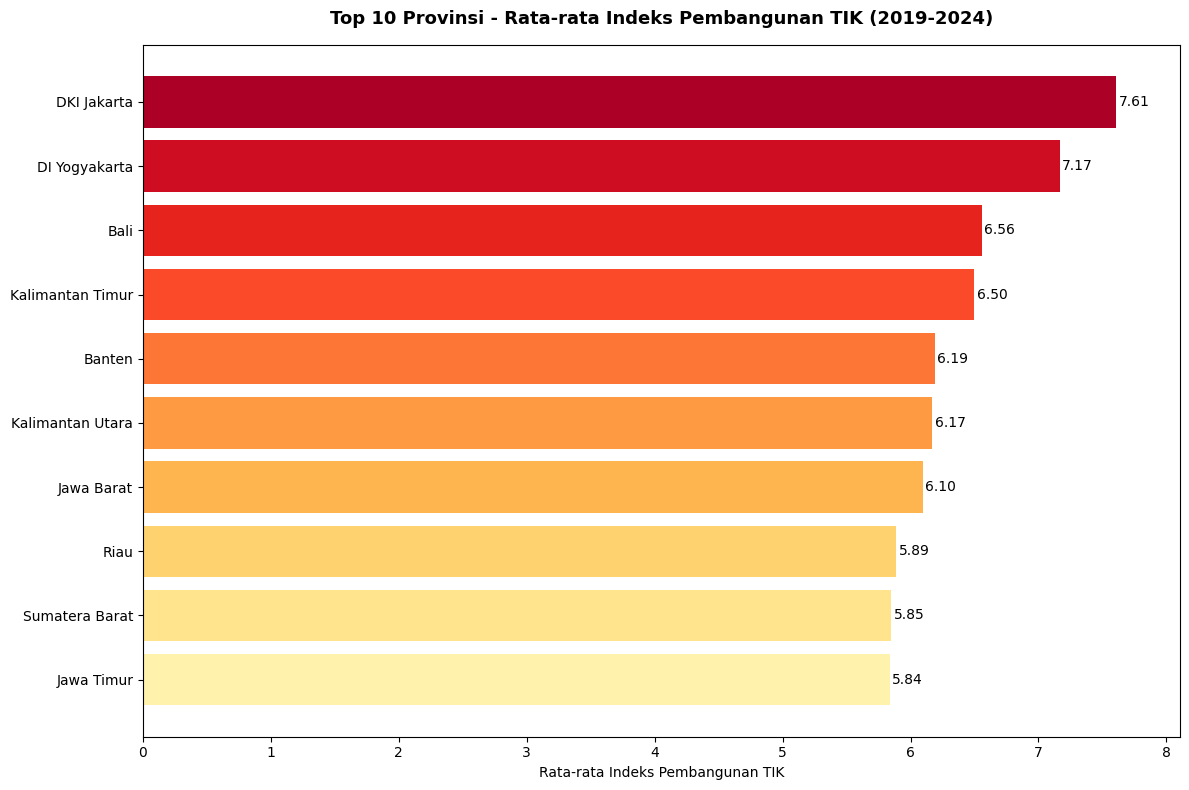

In [ ]:
df_iptik_plot = df_iptik_merged.copy().reset_index()
df_iptik_plot['IPTIK_avg'] = df_iptik_plot[['2019','2020','2021','2022','2023','2024']].mean(axis=1)

aps_cols_1315 = ['age 13-15 2020','age 13-15 2021','age 13-15 2022','age 13-15 2023','age 13-15 2024','age 13-15 2025']
aps_cols_1618 = ['age 16-18 2020','age 16-18 2021','age 16-18 2022','age 16-18 2023','age 16-18 2024','age 16-18 2025']
aps_cols_1923 = ['age 19-23 2020','age 19-23 2021','age 19-23 2022','age 19-23 2023','age 19-23 2024','age 19-23 2025']

df_aps_plot = df_aps_merged.copy().reset_index()
df_aps_plot['APS_avg'] = df_aps_plot[aps_cols_1923].mean(axis=1)

top10_iptik = df_iptik_plot.nlargest(10, 'IPTIK_avg')

plt.figure(figsize=(12, 8))
bars = plt.barh(
    top10_iptik['Provinsi'][::-1],
    top10_iptik['IPTIK_avg'][::-1],
    color=sns.color_palette('YlOrRd', 10)
)
plt.title('Top 10 Provinsi - Rata-rata Indeks Pembangunan TIK (2019-2024)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rata-rata Indeks Pembangunan TIK')
plt.xlim(0, top10_iptik['IPTIK_avg'].max() + 0.5)
for bar, val in zip(bars, top10_iptik['IPTIK_avg'][::-1]):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

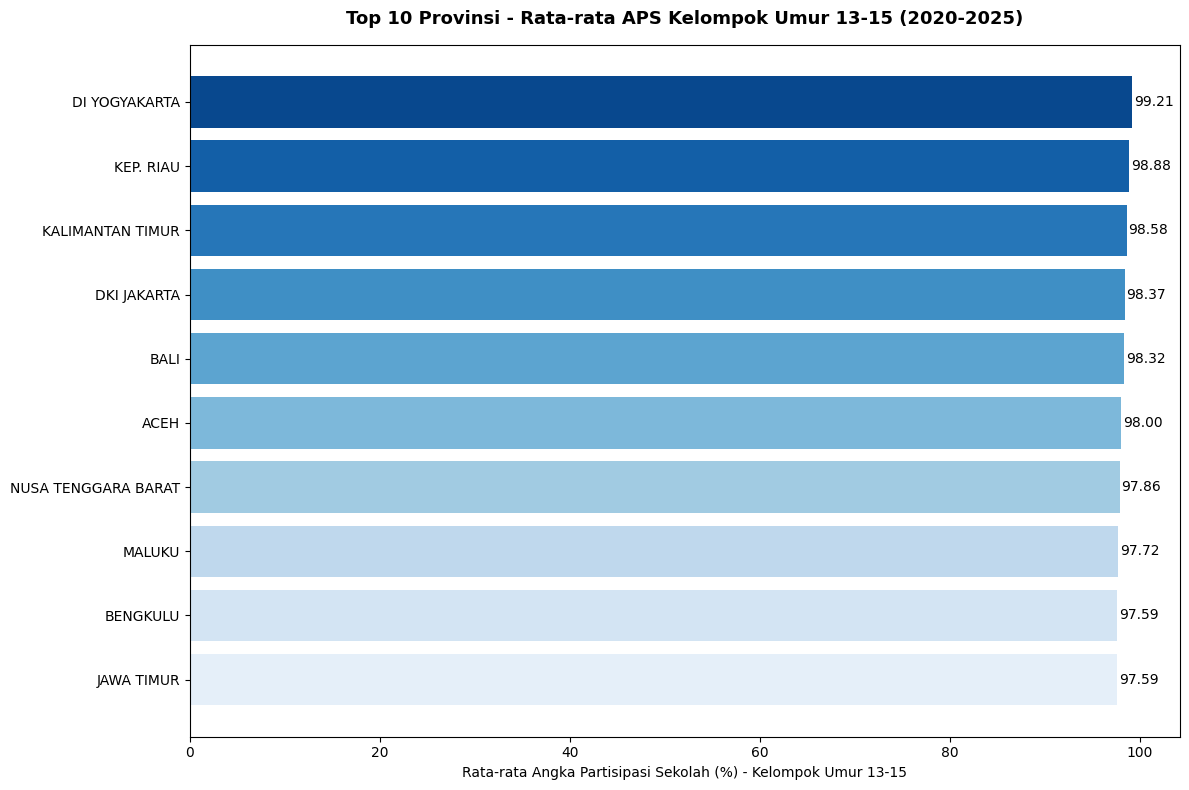

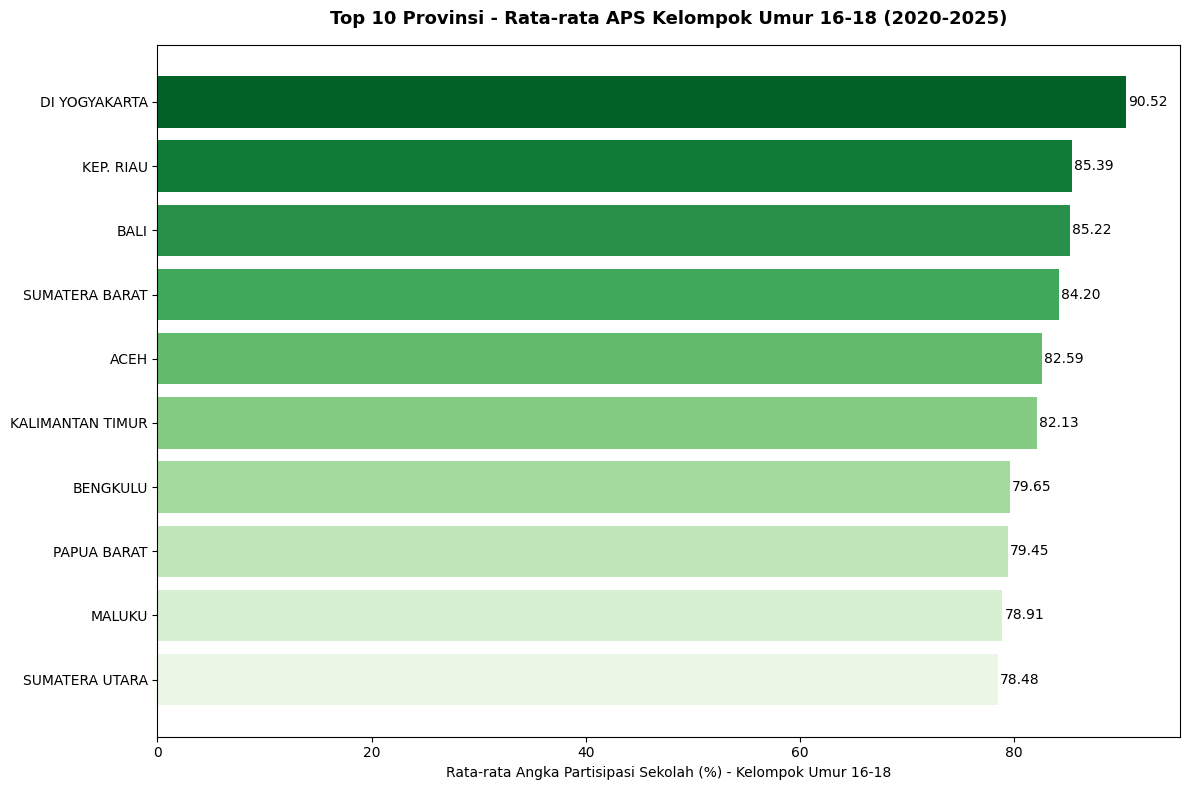

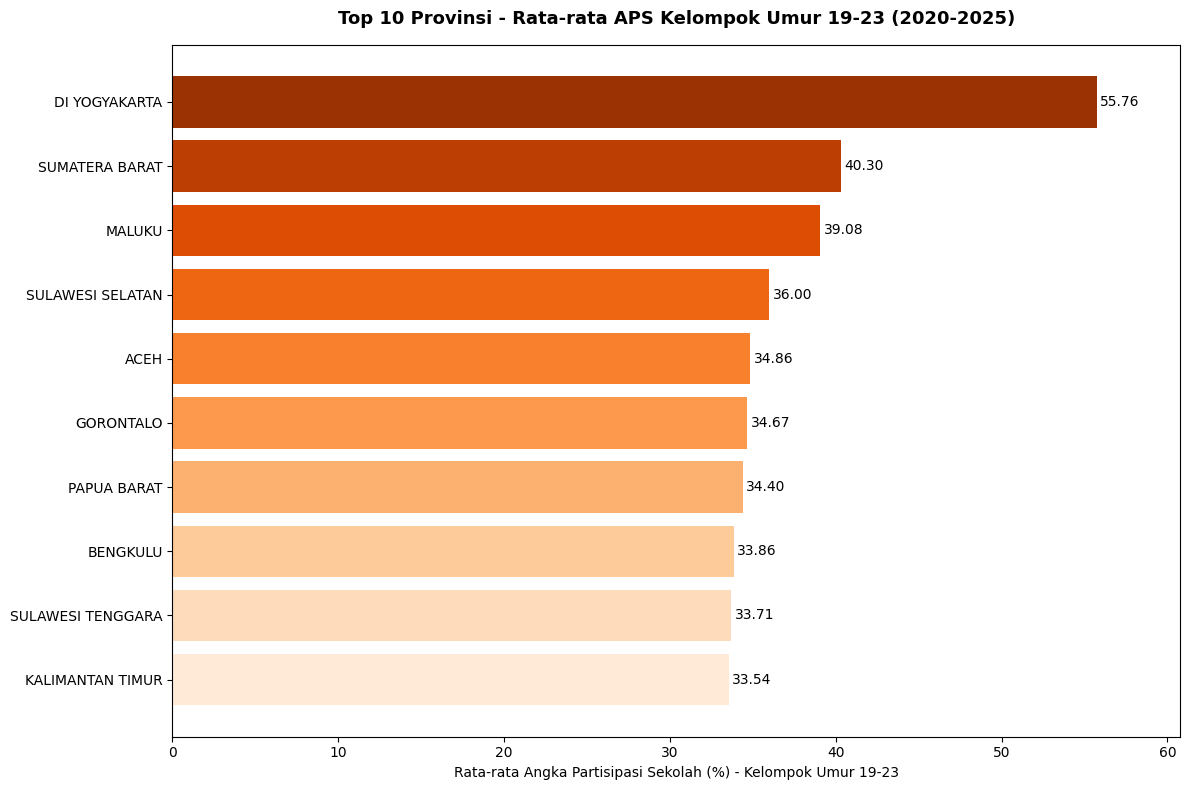

In [ ]:
aps_cols_1315 = ['age 13-15 2020','age 13-15 2021','age 13-15 2022','age 13-15 2023','age 13-15 2024','age 13-15 2025']
aps_cols_1618 = ['age 16-18 2020','age 16-18 2021','age 16-18 2022','age 16-18 2023','age 16-18 2024','age 16-18 2025']
aps_cols_1923 = ['age 19-23 2020','age 19-23 2021','age 19-23 2022','age 19-23 2023','age 19-23 2024','age 19-23 2025']


df_aps_plot['APS_avg_1315'] = df_aps_plot[aps_cols_1315].mean(axis=1)
df_aps_plot['APS_avg_1618'] = df_aps_plot[aps_cols_1618].mean(axis=1)
df_aps_plot['APS_avg_1923'] = df_aps_plot[aps_cols_1923].mean(axis=1)

age_groups = {
    'APS_avg_1315': ('Kelompok Umur 13-15', 'Blues'),
    'APS_avg_1618': ('Kelompok Umur 16-18', 'Greens'),
    'APS_avg_1923': ('Kelompok Umur 19-23', 'Oranges'),
}

for col, (label, palette) in age_groups.items():
    top10 = df_aps_plot.nlargest(10, col)

    plt.figure(figsize=(12, 8))
    bars = plt.barh(
        top10['Provinsi'][::-1],
        top10[col][::-1],
        color=sns.color_palette(palette, 10)
    )
    plt.title(f'Top 10 Provinsi - Rata-rata APS {label} (2020-2025)',
              fontsize=13, fontweight='bold', pad=15)
    plt.xlabel(f'Rata-rata Angka Partisipasi Sekolah (%) - {label}')
    plt.xlim(0, top10[col].max() + 5)
    for bar, val in zip(bars, top10[col][::-1]):
        plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

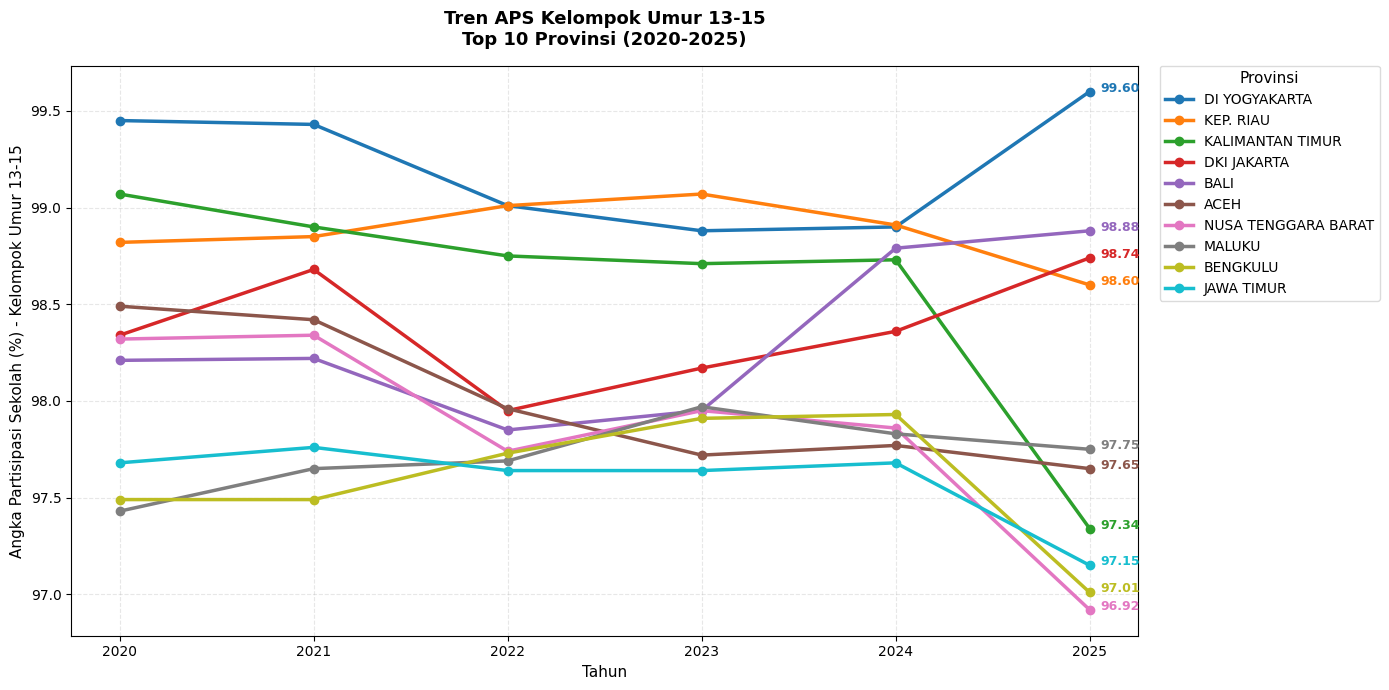

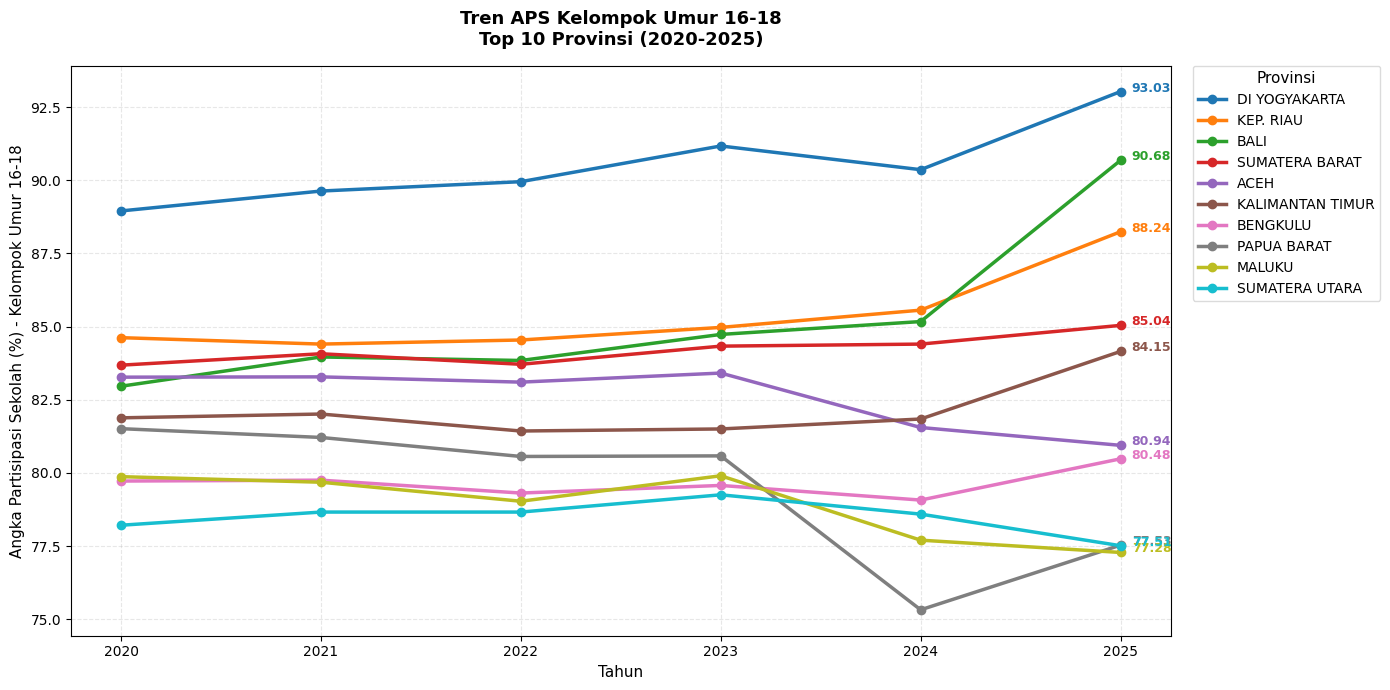

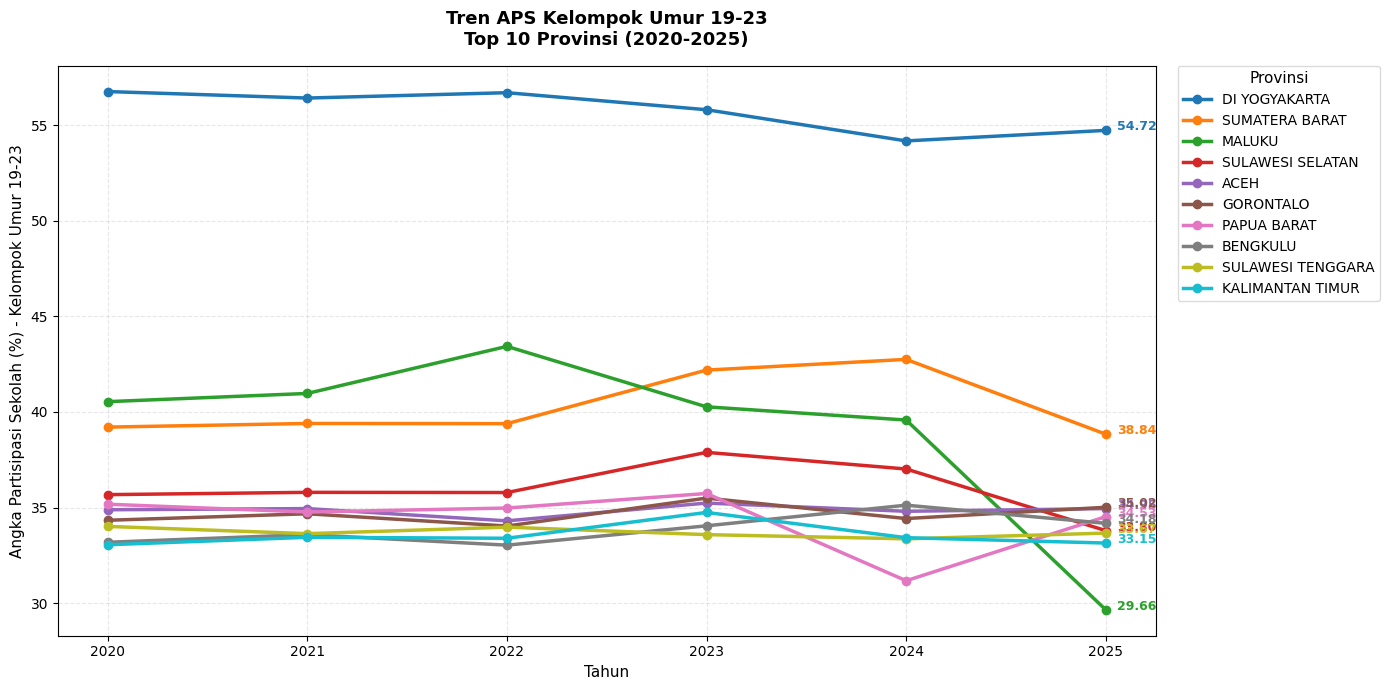

In [ ]:
aps_cols_1315 = ['age 13-15 2020','age 13-15 2021','age 13-15 2022','age 13-15 2023','age 13-15 2024','age 13-15 2025']
aps_cols_1618 = ['age 16-18 2020','age 16-18 2021','age 16-18 2022','age 16-18 2023','age 16-18 2024','age 16-18 2025']
aps_cols_1923 = ['age 19-23 2020','age 19-23 2021','age 19-23 2022','age 19-23 2023','age 19-23 2024','age 19-23 2025']


df_aps_plot = df_aps_merged.copy().reset_index()
df_aps_plot['APS_avg_1315'] = df_aps_plot[aps_cols_1315].mean(axis=1)
df_aps_plot['APS_avg_1618'] = df_aps_plot[aps_cols_1618].mean(axis=1)
df_aps_plot['APS_avg_1923'] = df_aps_plot[aps_cols_1923].mean(axis=1)

aps_years = ['2020', '2021', '2022', '2023', '2024', '2025']

age_config = {
    'APS_avg_1315': {
        'cols': aps_cols_1315,
        'label': 'Kelompok Umur 13-15',
    },
    'APS_avg_1618': {
        'cols': aps_cols_1618,
        'label': 'Kelompok Umur 16-18',
    },
    'APS_avg_1923': {
        'cols': aps_cols_1923,
        'label': 'Kelompok Umur 19-23',
    },
}

for avg_col, config in age_config.items():
    top10 = df_aps_plot.nlargest(10, avg_col)['Provinsi'].tolist()
    colors = sns.color_palette('tab10', 10)

    fig, ax = plt.subplots(figsize=(14, 7))

    for i, prov in enumerate(top10):
        values = df_aps_plot[df_aps_plot['Provinsi'] == prov][config['cols']].values.flatten()
        ax.plot(aps_years, values, marker='o', label=prov,
                color=colors[i], linewidth=2.5)
        ax.annotate(f'{values[-1]:.2f}',
                    (aps_years[-1], values[-1]),
                    textcoords='offset points',
                    xytext=(8, 0),
                    fontsize=9,
                    color=colors[i],
                    fontweight='bold')

    ax.set_title(f'Tren APS {config["label"]}\nTop 10 Provinsi (2020-2025)',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Tahun', fontsize=11)
    ax.set_ylabel(f'Angka Partisipasi Sekolah (%) - {config["label"]}', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(aps_years)

    # Legend outside to the right
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        fontsize=10,
        framealpha=0.7,
        title='Provinsi',
        title_fontsize=11
    )

    plt.tight_layout()
    plt.show()

=== Merged rows: 33 ===


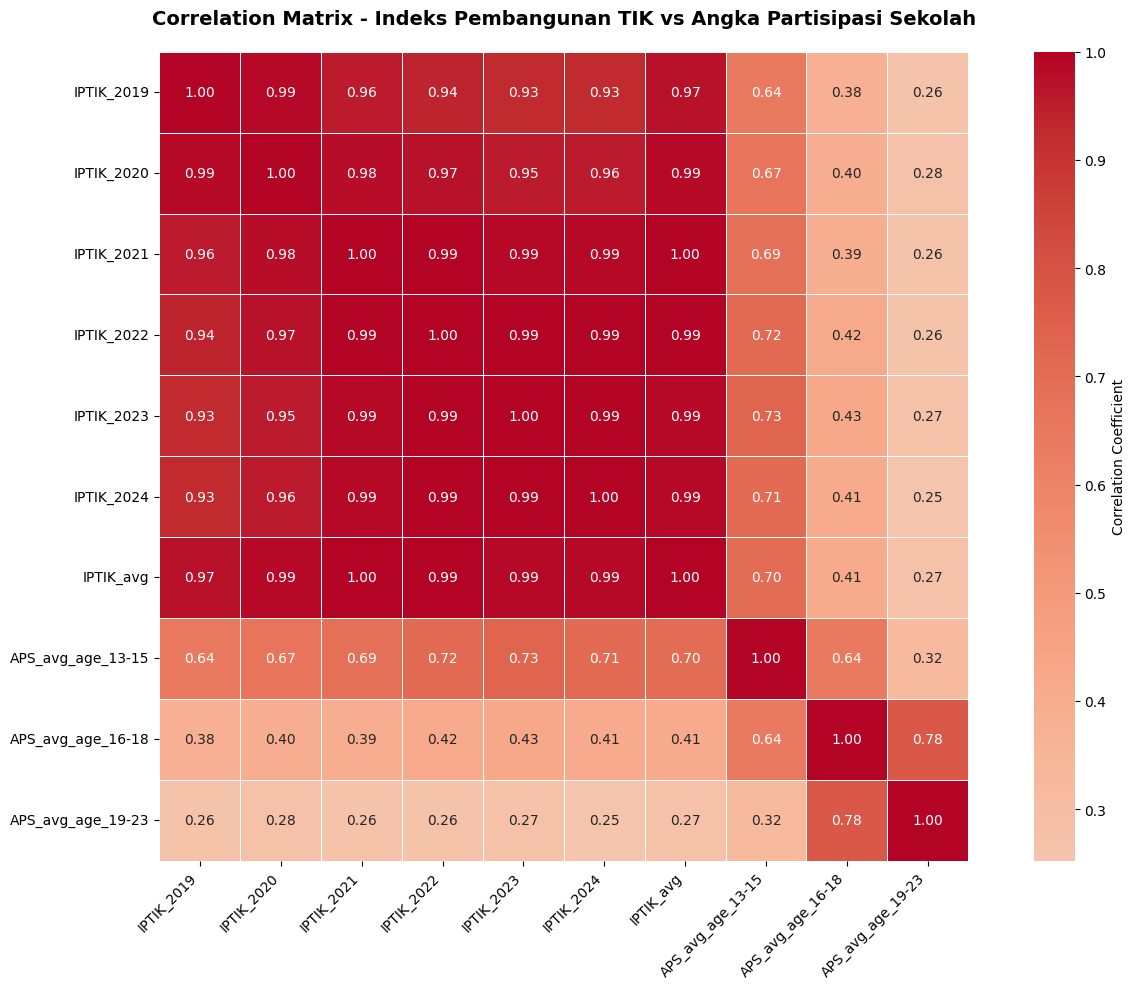


=== Korelasi IPTIK_avg vs APS ===
APS_avg_age_13-15    0.699282
APS_avg_age_16-18    0.408232
APS_avg_age_19-23    0.268779

=== Korelasi APS_avg_age_19-23 vs IPTIK ===
IPTIK_2020    0.275513
IPTIK_2023    0.272856
IPTIK_avg     0.268779
IPTIK_2019    0.264340
IPTIK_2021    0.264204
IPTIK_2022    0.262344
IPTIK_2024    0.252409


In [ ]:
df_iptik_corr = df_iptik_merged.copy().reset_index()
df_iptik_corr['Provinsi'] = df_iptik_corr['Provinsi'].str.upper().str.strip()
df_iptik_corr = df_iptik_corr.rename(columns={
    '2019': 'IPTIK_2019', '2020': 'IPTIK_2020',
    '2021': 'IPTIK_2021', '2022': 'IPTIK_2022',
    '2023': 'IPTIK_2023', '2024': 'IPTIK_2024',
})
df_iptik_corr['IPTIK_avg'] = df_iptik_corr[['IPTIK_2019','IPTIK_2020','IPTIK_2021',
                                              'IPTIK_2022','IPTIK_2023','IPTIK_2024']].mean(axis=1)

df_aps_corr = df_aps_merged.copy().reset_index()
df_aps_corr['Provinsi'] = df_aps_corr['Provinsi'].str.upper().str.strip()
df_aps_corr['APS_avg_1315'] = df_aps_corr[aps_cols_1315].mean(axis=1)
df_aps_corr['APS_avg_1618'] = df_aps_corr[aps_cols_1618].mean(axis=1)
df_aps_corr['APS_avg_1923'] = df_aps_corr[aps_cols_1923].mean(axis=1)


province_mapping = {
    'KEP. RIAU'       : 'KEPULAUAN RIAU',
    'KALIMANTAN UTARA': 'KALTARA',
}

df_iptik_corr['Provinsi'] = df_iptik_corr['Provinsi'].replace(province_mapping)
df_aps_corr['Provinsi']   = df_aps_corr['Provinsi'].replace(province_mapping)


df_corr = df_iptik_corr[['Provinsi','IPTIK_2019','IPTIK_2020','IPTIK_2021',
                           'IPTIK_2022','IPTIK_2023','IPTIK_2024','IPTIK_avg']].merge(
    df_aps_corr[['Provinsi','APS_avg_1315','APS_avg_1618','APS_avg_1923']],
    on='Provinsi', how='inner'
).drop(columns='Provinsi')


df_corr = df_corr.rename(columns={
    'APS_avg_1315': 'APS_avg_age_13-15',
    'APS_avg_1618': 'APS_avg_age_16-18',
    'APS_avg_1923': 'APS_avg_age_19-23',
})

print(f"=== Merged rows: {len(df_corr)} ===")

corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix - Indeks Pembangunan TIK vs Angka Partisipasi Sekolah',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n=== Korelasi IPTIK_avg vs APS ===")
print(corr_matrix['IPTIK_avg'][['APS_avg_age_13-15','APS_avg_age_16-18','APS_avg_age_19-23']]
      .sort_values(ascending=False).to_string())

print("\n=== Korelasi APS_avg_age_19-23 vs IPTIK ===")
print(corr_matrix['APS_avg_age_19-23'][['IPTIK_2019','IPTIK_2020','IPTIK_2021',
                                         'IPTIK_2022','IPTIK_2023','IPTIK_2024','IPTIK_avg']]
      .sort_values(ascending=False).to_string())

Setelah melakukan EDA, kami melanjutkannya ke tahap visualisasi data serta menilai korelasi antar 2 tipe data. Kami menggunakan 2 teknik visualisasi yakni menggunakan ***bar chart*** dan ***line chart***.

Hasil dalam bentuk ***Bar Chart*** tetaplah sama seperti apa yang kami jabarkan di proses EDA. Namun untuk hasil dalam bentuk ***Line Chart*** memberikan sebuah insight grafik yang menarik.

Pada hasil data APS di dalam ***Line Chart***, kami melihat trend perkembangan anak - anak dengan umur 13 - 15 tahun cenderung stabil ada yang naik dan ada yang turun namun masih di dalam rentang >90% nilai ini masih tergolong sangat tinggi. Sedangkan untuk anak - anak dengan umur 16-18 tahun memiliki rata - rata trend yang cenderung (mayoritas) provinsinya menggambarkan kenaikan.

Namun untuk anak - anak dengan umur 19-23 tahun, terdapat perbedaan yang sangat signifikan antara 1 provinsi dengan provinsi lainnya. Sesuai dengan pemaparan kami di dalam proses EDA, provinsi DI Yogyakarta memiliki APS yang cukup stabil dan paling tinggi di antara semuanya. Sedangkan 9 provinsi lainnya memberikan gambaran trend yang cenderung stagnan dan terindikasi mengalami penurunan. Hal ini memicu sebuah pertanyaan mengenai apakah ada korelasinya dengan tingkat IPTIK pada sebuah provinsi tersebut. Kami melakukan pendalaman analisis dengan menggunakan matrix korelasi untuk mencari jawaban dari pertanyaan bisnis kami.

Setelah menerapkan matrix korelasi, kami menemukan bahwa korelasi antara data IPTIK dari tahun 2019 - 2024 memiliki pengaruh yang signifikan untuk tingkat APS pada jenjang umur 13-15 tahun yang di mana anak - anak pada umur ini memang sangat penting untuk disediakan sebuah perangkat Teknologi serta belajar dasar - dasar hingga tingkat menengah dalam pemanfaatan teknologi dengan lebih produktif lagi. Semakin anak tersebut tumbuh, ternyata pengaruh pembangunan IPTIK tidaklah terlalu signifikan dengan asumsi bahwa anak - anak yang telah bertumbuh ini secara rata - rata telah memiliki minimal 1 perangkat lunak (dapat berupa HP, Laptop, Tablet,dsb) sehingga anak - anak tersebut dapat secara bebas menggali informasi dari media sosial.

Sehingga jawaban dari pertanyaan bisnis yang telah kami lontarkan adalah tingkat pembangunan TIK memang sangatlah penting untuk perkembangan awal anak - anak pada usia dini, namun seiring pertumbuhan, bukan tingkat pembangunan TIK lah yang memotivasi anak - anak untuk memperjuangkan studi nya ke tahap yang lebih tinggi namun jawaban yang kami dapatkan adalah motivasi pribadi anak - anak serta kemampuan finansial keluarga merekalah yang menjadi pedoman apakah siswa tersebut setelah lulus SMA ingin melanjutkan ke jenjang perkuliahan atau tidak.

Maka dari itu, kami Scholarship Lab adalah solusi dan jawaban untuk mengatasi tantangan finansial maupun de-motivasi anak - anak lulusan SMA untuk membimbing mereka keluar dari zona keputusasaan dan keraguan mereka dan menjodohkan siswa - siswa ini dengan beasiswa ke universitas impian mereka.

A/B TESTING (IPTIK)

In [ ]:
df_aps_fe = df_aps_merged.copy().reset_index()
if 'Rank' in df_aps_fe.columns:
    df_aps_fe = df_aps_fe.drop(columns=['Rank'])
if 'index' in df_aps_fe.columns:
    df_aps_fe = df_aps_fe.drop(columns=['index'])

df_aps_fe['Provinsi']   = df_aps_fe['Provinsi'].str.strip().str.upper()
df_iptik_fe['Provinsi'] = df_iptik_fe['Provinsi'].str.strip().str.upper()

df_aps_fe['Provinsi'] = df_aps_fe['Provinsi'].replace({
    'KEP. RIAU' : 'KEPULAUAN RIAU',
    'INDONESIA' : None
})

df_aps_fe = df_aps_fe[df_aps_fe['Provinsi'].notna()]
df_aps_fe = df_aps_fe[df_aps_fe['Provinsi'] != 'INDONESIA']

aps_provs   = set(df_aps_fe['Provinsi'])
iptik_provs = set(df_iptik_fe['Provinsi'])

print("=== In IPTIK but NOT in APS ===")
print(iptik_provs - aps_provs)

print("\n=== In APS but NOT in IPTIK ===")
print(aps_provs - iptik_provs)

print(f"\n=== Matching provinces: {len(iptik_provs & aps_provs)} ===")

print("\n=== APS Columns ===")
print(df_aps_fe.columns.tolist())

print(f"\n=== APS shape: {df_aps_fe.shape} ===")
print(f"=== IPTIK shape: {df_iptik_fe.shape} ===")

=== In IPTIK but NOT in APS ===
set()

=== In APS but NOT in IPTIK ===
{'KEPULAUAN RIAU'}

=== Matching provinces: 33 ===

=== APS Columns ===
['Provinsi', 'age 13-15 2020', 'age 16-18 2020', 'age 19-23 2020', 'age 13-15 2021', 'age 16-18 2021', 'age 19-23 2021', 'age 13-15 2022', 'age 16-18 2022', 'age 19-23 2022', 'age 13-15 2023', 'age 16-18 2023', 'age 19-23 2023', 'age 13-15 2024', 'age 16-18 2024', 'age 19-23 2024', 'age 13-15 2025', 'age 16-18 2025', 'age 19-23 2025']

=== APS shape: (34, 19) ===
=== IPTIK shape: (33, 20) ===


Top 10 provinces    → ['DKI JAKARTA', 'DI YOGYAKARTA', 'BALI', 'KALIMANTAN TIMUR', 'BANTEN', 'KALIMANTAN UTARA', 'JAWA BARAT', 'RIAU', 'SUMATERA BARAT', 'JAWA TIMUR']
Bottom 10 provinces → ['PAPUA', 'NUSA TENGGARA TIMUR', 'MALUKU UTARA', 'SULAWESI BARAT', 'KALIMANTAN BARAT', 'NUSA TENGGARA BARAT', 'PAPUA BARAT', 'LAMPUNG', 'SULAWESI TENGAH', 'ACEH']

SPLIT - IPTIK METRICS (Top 10 vs Bottom 10)


,Metric,Mean Top10,Mean Bottom10,T-statistic,T p-value,T Significant,U-statistic,U p-value,U Significant,Cohen's d,Effect Size
Rank,,,,,,,,,,,
1,IPTIK_2019,6.030,4.556,5.4769,0.0000,Yes ✓,100.0,0.0002,Yes ✓,2.4493,Large
2,IPTIK_2020,6.242,4.852,5.0890,0.0001,Yes ✓,100.0,0.0002,Yes ✓,2.2759,Large
3,IPTIK_2021,6.368,5.166,4.2424,0.0005,Yes ✓,100.0,0.0002,Yes ✓,1.8972,Large
4,IPTIK_2022,6.493,5.265,4.1803,0.0006,Yes ✓,100.0,0.0002,Yes ✓,1.8695,Large
5,IPTIK_2024,6.659,5.553,3.8039,0.0013,Yes ✓,100.0,0.0002,Yes ✓,1.7011,Large
6,IPTIK_2023,6.523,5.451,3.6862,0.0017,Yes ✓,100.0,0.0002,Yes ✓,1.6485,Large



--- Significant Results (p < 0.05) ---


,Metric,Mean Top10,Mean Bottom10,T p-value,U p-value,Cohen's d,Effect Size
Rank,,,,,,,
1,IPTIK_2019,6.030,4.556,0.0000,0.0002,2.4493,Large
2,IPTIK_2020,6.242,4.852,0.0001,0.0002,2.2759,Large
3,IPTIK_2021,6.368,5.166,0.0005,0.0002,1.8972,Large
4,IPTIK_2022,6.493,5.265,0.0006,0.0002,1.8695,Large
5,IPTIK_2024,6.659,5.553,0.0013,0.0002,1.7011,Large
6,IPTIK_2023,6.523,5.451,0.0017,0.0002,1.6485,Large



SPLIT - APS age 13-15 (Top 10 vs Bottom 10 IPTIK)


...


--- Significant Results (p < 0.05) ---


,Metric,Mean Top10,Mean Bottom10,T p-value,U p-value,Cohen's d,Effect Size
Rank,,,,,,,
1,age 16-18 2025,83.107,77.061,0.0166,0.0257,1.1817,Large



SPLIT - APS age 19-23 (Top 10 vs Bottom 10 IPTIK)


,Metric,Mean Top10,Mean Bottom10,T-statistic,T p-value,T Significant,U-statistic,U p-value,U Significant,Cohen's d,Effect Size
Rank,,,,,,,,,,,
1,age 19-23 2025,33.885,29.088,1.5094,0.1485,No ✗,67.0,0.2123,No ✗,0.6750,Medium
2,age 19-23 2024,34.228,30.099,1.3526,0.1929,No ✗,64.5,0.2897,No ✗,0.6049,Medium
3,age 19-23 2023,33.852,29.737,1.2884,0.2139,No ✗,62.0,0.3847,No ✗,0.5762,Medium
4,age 19-23 2022,32.421,28.917,1.0389,0.3126,No ✗,58.0,0.5708,No ✗,0.4646,Small
5,age 19-23 2021,32.099,29.145,0.8797,0.3906,No ✗,55.0,0.7337,No ✗,0.3934,Small
6,age 19-23 2020,31.834,28.934,0.8468,0.4082,No ✗,55.0,0.7337,No ✗,0.3787,Small



--- Significant Results (p < 0.05) ---
No significant results found.


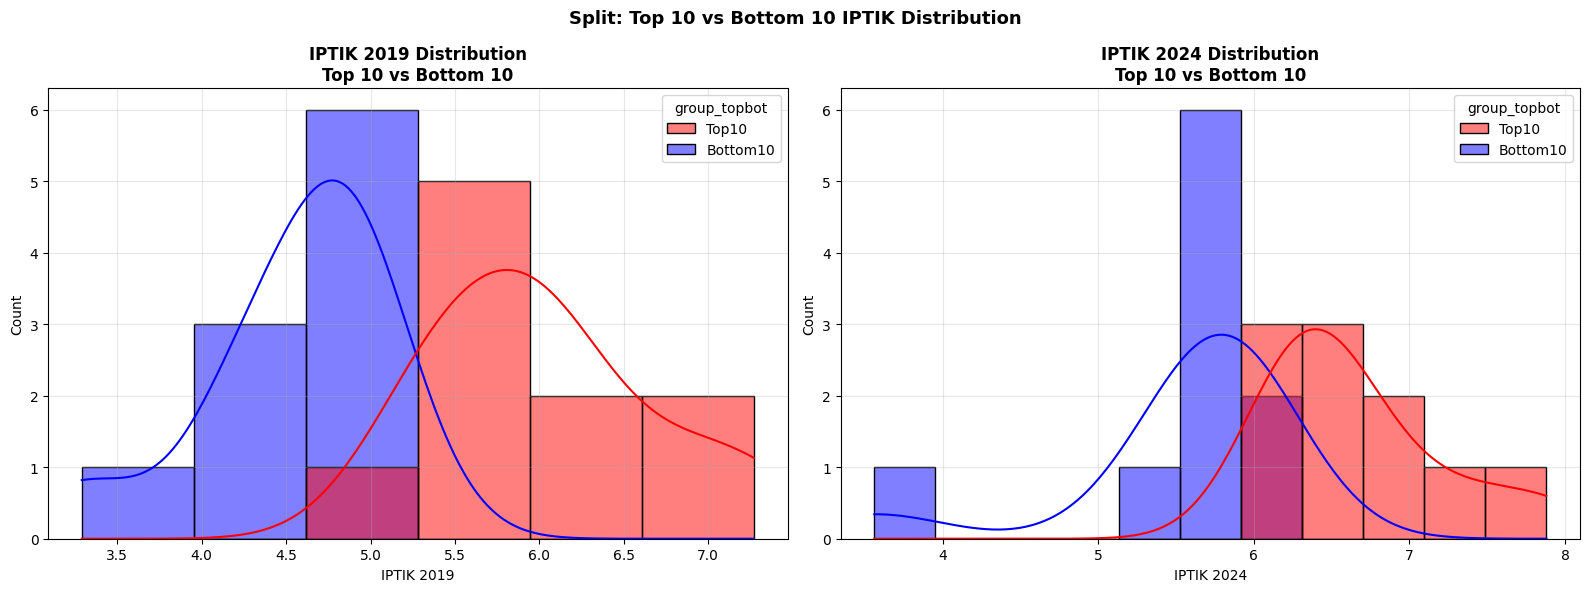

In [ ]:

df_iptik_fe['IPTIK_avg'] = df_iptik_fe[['2019','2020','2021','2022','2023','2024']].mean(axis=1)

iptik_metrics  = ['2019','2020','2021','2022','2023','2024']
aps_years_list = ['2020','2021','2022','2023','2024','2025']
aps_age_groups = ['age 13-15','age 16-18','age 19-23']

metric_rename = {
    '2019': 'IPTIK_2019', '2020': 'IPTIK_2020',
    '2021': 'IPTIK_2021', '2022': 'IPTIK_2022',
    '2023': 'IPTIK_2023', '2024': 'IPTIK_2024',
}


def ab_test(group_a, group_b, metric, label_a='Group A', label_b='Group B'):
    a = group_a[metric].dropna()
    b = group_b[metric].dropna()
    if len(a) < 2 or len(b) < 2:
        return None

    t_stat, t_pval = stats.ttest_ind(a, b)
    u_stat, u_pval = stats.mannwhitneyu(a, b, alternative='two-sided')
    pooled_std     = np.sqrt((a.std()**2 + b.std()**2) / 2)
    cohens_d       = (a.mean() - b.mean()) / pooled_std if pooled_std != 0 else 0

    return {
        'Metric'          : metric,
        f'Mean {label_a}' : round(a.mean(), 4),
        f'Mean {label_b}' : round(b.mean(), 4),
        'T-statistic'     : round(t_stat, 4),
        'T p-value'       : round(t_pval, 4),
        'T Significant'   : 'Yes ✓' if t_pval < 0.05 else 'No ✗',
        'U-statistic'     : round(u_stat, 4),
        'U p-value'       : round(u_pval, 4),
        'U Significant'   : 'Yes ✓' if u_pval < 0.05 else 'No ✗',
        "Cohen's d"       : round(cohens_d, 4),
        'Effect Size'     : 'Large' if abs(cohens_d) >= 0.8 else
                            'Medium' if abs(cohens_d) >= 0.5 else 'Small'
    }

def display_results(df_result, label_a, label_b):
    df_result['Metric'] = df_result['Metric'].replace(metric_rename)
    df_result = df_result.reindex(
        df_result["Cohen's d"].abs().sort_values(ascending=False).index
    )
    df_result.index = range(1, len(df_result) + 1)
    df_result.index.name = 'Rank'
    display(df_result)

    print(f"\n--- Significant Results (p < 0.05) ---")
    sig = df_result[df_result['T Significant'] == 'Yes ✓']
    if len(sig) > 0:
        display(sig[[
            'Metric', f'Mean {label_a}', f'Mean {label_b}',
            'T p-value', 'U p-value', "Cohen's d", 'Effect Size'
        ]])
    else:
        print("No significant results found.")

# ============================================================
# SPLIT: Top 10 vs Bottom 10
# ============================================================

top10_provs    = df_iptik_fe.nlargest(10, 'IPTIK_avg')['Provinsi'].tolist()
bottom10_provs = df_iptik_fe.nsmallest(10, 'IPTIK_avg')['Provinsi'].tolist()

df_iptik_fe['group_topbot'] = df_iptik_fe['Provinsi'].apply(
    lambda x: 'Top10' if x in top10_provs
    else ('Bottom10' if x in bottom10_provs else None)
)
df_aps_fe['group_topbot'] = df_aps_fe['Provinsi'].apply(
    lambda x: 'Top10' if x in top10_provs
    else ('Bottom10' if x in bottom10_provs else None)
)

top10_iptik    = df_iptik_fe[df_iptik_fe['group_topbot'] == 'Top10']
bottom10_iptik = df_iptik_fe[df_iptik_fe['group_topbot'] == 'Bottom10']
top10_aps      = df_aps_fe[df_aps_fe['group_topbot'] == 'Top10']
bottom10_aps   = df_aps_fe[df_aps_fe['group_topbot'] == 'Bottom10']

print(f"Top 10 provinces    → {top10_provs}")
print(f"Bottom 10 provinces → {bottom10_provs}")

# ============================================================
# RUN TESTS - IPTIK
# ============================================================

print("\n" + "="*60)
print("SPLIT - IPTIK METRICS (Top 10 vs Bottom 10)")
print("="*60)

iptik_results = []
for metric in iptik_metrics:
    if metric in top10_iptik.columns and metric in bottom10_iptik.columns:
        result = ab_test(top10_iptik, bottom10_iptik, metric, 'Top10', 'Bottom10')
        if result:
            iptik_results.append(result)

if len(iptik_results) == 0:
    print("No metrics found")
else:
    df_iptik_ab2 = pd.DataFrame(iptik_results)
    display_results(df_iptik_ab2, 'Top10', 'Bottom10')

# ============================================================
# RUN TESTS - APS
# ============================================================

for age in aps_age_groups:
    age_tag     = age.replace(' ', '_').replace('-', '_')
    aps_metrics = [f'{age} {yr}' for yr in aps_years_list]

    print(f"\n{'='*60}")
    print(f"SPLIT - APS {age} (Top 10 vs Bottom 10 IPTIK)")
    print(f"{'='*60}")

    aps_results = []
    for metric in aps_metrics:
        if metric in top10_aps.columns and metric in bottom10_aps.columns:
            result = ab_test(top10_aps, bottom10_aps, metric, 'Top10', 'Bottom10')
            if result:
                aps_results.append(result)

    if len(aps_results) == 0:
        print("No metrics found")
        print(f"Available columns: {df_aps_fe.columns.tolist()}")
        continue

    df_aps_ab2 = pd.DataFrame(aps_results)
    display_results(df_aps_ab2, 'Top10', 'Bottom10')

# ============================================================
# VISUALIZATION
# ============================================================

df_plot = df_iptik_fe[df_iptik_fe['group_topbot'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, year in zip(axes, ['2019', '2024']):
    sns.histplot(data=df_plot, x=year, hue='group_topbot',
                 palette={'Top10': 'red', 'Bottom10': 'blue'},
                 kde=True, alpha=0.5, ax=ax)
    ax.set_title(f'IPTIK {year} Distribution\nTop 10 vs Bottom 10',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f'IPTIK {year}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Split: Top 10 vs Bottom 10 IPTIK Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



Setelah melakukan visualisasi data dan matriks korelasi, kami selanjutnya melaksanakan salah satu ***side quest*** data scientist yakni melakukan uji A/B.

Menurut hasil yang telah kami dapat adalah data IPTIK memberikan hasil yang sehat yang di mana dari tahun 2019 - 2024 indikator cohen'd terus menurun secara konsisten setiap tahunnya yang mengindikasikan bahwa jarak antara pembangunan IPTIK pada 10 provinsi teratas dengan 10 provinsi terbawah menjadi lebih kecil. Meskipun pada tahun 2024 ada indikasi kenaikan, namun secara rata - rata hasil cohen'd nya tergolong sehat dan menunjukkan perkembangan pembangunan TIK di wilayah - wilayah yang tertinggal. Secara garis besar, hasil statistik khususnya P-Value menunjukkan hasil < 0.05 yang artinya signifikan.

Berbeda halnya dengan data APS dari tahun 2020 - 2025, untuk anak - anak dengan rentang umur 13-15 memiliki 2 hasil yang signifikan yang mengindikasikan bahwa pembangunan IPTIK di 10 provinsi teratas dan terbawah memang memiliki korelasi dan pengaruh untuk perkembangan anak - anak di rentang umur ini.

Selain itu, anak - anak dengan umur 16-23 memiliki hasil yang secara mayoritas tidaklah signifikan. Hal ini mencerminkan bahwa pada rentang umur ini, pembangunan IPTIK di 10 provinsi teratas dengan 10 provinsi terbawah sudah memiliki kapasitas pembangunan yang memadai sehingga tidak menjadi sebuah masalah utama kepada anak - anak untuk melaju ke jenjang pendidikan yang lebih tinggi.


Kesimpulan

Kesimpulan daripada hasil jawaban yang telah dilakukan adalah anak - anak khususnya dengan rentang umur 19-23 tahun tidak memiliki kekurangan akses terhadap informasi digital maupun alat - alat komunikasi atau elektronik yang dapat digunakan, namun terletak pada kondisi mental anak - anak tersebut yang dipengaruhi oleh ***mindset***, motivasi, kekuatan finansial serta ketersediaan informasi beasiswa yang memadai dan transparan yang juga dipengaruhi oleh seberapa kuatnya prestasi siswa tersebut yang di mana akan mempengaruhi anak tersebut memasuki sebuah kelompok pergaulan yang dapat menjadi access informasi mengenai berbagai beasiswa yang tersedia sesuai dengan minat dan tujuan siswa tersebut.